# Logistic Regression to predict if users want to sign up for a long term deposit.

## Business Insight

Long-term deposits allow banks to hold money for a specific period of time, allowing the bank to use that money to enhance its investments. Marketing campaigns for this product are based on phone calls. If a user is not available at a given time, then they will be called back at another time.

## Description of the problem

The Portuguese bank is experiencing a decline in revenue, so they want to be able to identify existing customers who are more likely to take out a long-term deposit. This will allow the bank to focus their marketing efforts on those customers and avoid wasting money and time on customers who are unlikely to sign up.

To address this problem we will create a ranking algorithm to help predict whether or not a customer will sign up for a long-term deposit.

### Import Libraries

In [1]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
from save_encoding_rules import save_encoding_rules

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency

# Machine Learning libraries
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Step 1 - Loading the dataset

Load your dataset and specify the target variable for your Logistic Regression model.
**Note:** Target variable should be binary (0/1) or categorical.

In [3]:
# Load your dataset
df = pd.read_csv('../data/raw/bank-marketing-campaign-data.csv',sep=';')  

# Define target variable (must be binary or categorical for logistic regression)
target_column = 'y' 

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Target Variable: {target_column}")

Dataset loaded successfully!
Shape: (41188, 21)
Target Variable: y


### Basic Data Overview

In [4]:
# Configuración para visualización mejorada de DataFrames
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', 100)      # Mostrar hasta 100 filas
pd.set_option('display.width', None)        # Ancho automático
pd.set_option('display.max_colwidth', 100)  # Ancho máximo de columnas
pd.set_option('display.float_format', '{:.2f}'.format)  # Formato para flotantes

In [5]:
# Display first few rows
print("First 5 rows:")
df.head()

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [6]:
# Display last few rows
print("Last 5 rows:")
df.tail()

Last 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.10,94.77,-50.80,1.03,4963.60,no


In [7]:
# Dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   4

In [8]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


### Missing Values Analysis

In [9]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    display(missing_df)
    
    # Visualize missing values
    plt.figure(figsize=(10, 6))
    missing_df['Percentage'].plot(kind='barh', color='coral')
    plt.title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage (%)')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found in the dataset!")

✓ No missing values found in the dataset!


### Detect the duplicates

In [10]:
# Check for duplicate rows
print("="*70)
print("DUPLICATE ROWS DETECTION")
print("="*70)

# Count total duplicates
total_duplicates = df.duplicated().sum()
duplicate_percentage = (total_duplicates / len(df)) * 100

print(f"\nTotal duplicate rows: {total_duplicates}")
print(f"Percentage of duplicates: {duplicate_percentage:.2f}%")

if total_duplicates > 0:
    print(f"\n⚠ {total_duplicates} duplicate rows found!")
    
    # Show duplicate rows
    print("\nDuplicate rows:")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    display(duplicates_df.head(20))  # Show first 20 duplicates
    
    # Options for handling duplicates
    print("\nOptions for handling duplicates:")
    print("   1. Keep first occurrence: df_clean = df.drop_duplicates(keep='first')")
    print("   2. Keep last occurrence:  df_clean = df.drop_duplicates(keep='last')")
    print("   3. Remove all duplicates: df_clean = df.drop_duplicates(keep=False)")
    
else:
    print("\n✓ No duplicate rows found in the dataset!")

DUPLICATE ROWS DETECTION

Total duplicate rows: 12
Percentage of duplicates: 0.03%

⚠ 12 duplicate rows found!

Duplicate rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.80,93.08,-47.10,1.42,5099.10,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.80,93.08,-47.10,1.42,5099.10,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.40,93.92,-42.70,4.96,5228.10,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.40,93.92,-42.70,4.96,5228.10,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.40,93.92,-42.70,4.97,5228.10,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.40,93.92,-42.70,4.97,5228.10,no
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.80,92.89,-46.20,1.31,5099.10,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.80,92.89,-46.20,1.31,5099.10,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.40,93.92,-42.70,4.97,5228.10,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.40,93.92,-42.70,4.97,5228.10,no



Options for handling duplicates:
   1. Keep first occurrence: df_clean = df.drop_duplicates(keep='first')
   2. Keep last occurrence:  df_clean = df.drop_duplicates(keep='last')
   3. Remove all duplicates: df_clean = df.drop_duplicates(keep=False)


## Step 2: Perform a full EDA

### Feature Type Identification

In [11]:
# Identify numeric and categorical features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target from feature lists if it's there
if target_column in numeric_features:
    numeric_features.remove(target_column)
if target_column in categorical_features:
    categorical_features.remove(target_column)

print(f"Numeric Features ({len(numeric_features)}):")
print(numeric_features)
print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)
print(f"\nTarget Variable: {target_column}")

Numeric Features (10):
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical Features (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Target Variable: y


### Statistical Summary

In [12]:
# Statistical summary of numeric features
if numeric_features:
    print("Statistical Summary - Numeric Features:")
    display(df[numeric_features].describe())
else:
    print("No numeric features in the dataset.")

Statistical Summary - Numeric Features:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [13]:
# Additional statistics: skewness and kurtosis
if numeric_features:
    stats_df = pd.DataFrame({
        'Skewness': df[numeric_features].skew(),
        'Kurtosis': df[numeric_features].kurtosis()
    })
    print("\nSkewness and Kurtosis:")
    display(stats_df)


Skewness and Kurtosis:


,Skewness,Kurtosis
age,0.78,0.79
duration,3.26,20.25
campaign,4.76,36.98
pdays,-4.92,22.23
previous,3.83,20.11
emp.var.rate,-0.72,-1.06
cons.price.idx,-0.23,-0.83
cons.conf.idx,0.30,-0.36
euribor3m,-0.71,-1.41
nr.employed,-1.04,-0.00


In [14]:
# Automated Analysis of Skewness and Kurtosis
if numeric_features:
    print("="*80)
    print("SKEWNESS AND KURTOSIS ANALYSIS")
    print("="*80)
    
    # Define interpretation functions
    def interpret_skewness(skew_value):
        """Interpret skewness value"""
        abs_skew = abs(skew_value)
        if abs_skew < 0.5:
            return "Fairly Symmetric ✓", "No transformation needed"
        elif abs_skew < 1:
            return "Moderately Skewed ⚠", "Consider transformation (log, sqrt)"
        else:
            direction = "Right (positive)" if skew_value > 0 else "Left (negative)"
            return f"Highly Skewed ({direction}) ⚠⚠", "Transformation recommended (log, box-cox)"
    
    def interpret_kurtosis(kurt_value):
        """Interpret kurtosis value"""
        if abs(kurt_value) < 1:
            return "Normal Tails ✓", "Distribution is close to normal"
        elif kurt_value > 3:
            return "Very Heavy Tails ⚠⚠", "Many outliers present"
        elif kurt_value > 1:
            return "Heavy Tails ⚠", "Some outliers present"
        else:
            return "Light Tails", "Fewer outliers than normal"
    
    # Analyze each feature
    transformation_needed = []
    
    for feature in numeric_features:
        skew_val = df[feature].skew()
        kurt_val = df[feature].kurtosis()
        
        skew_interp, skew_action = interpret_skewness(skew_val)
        kurt_interp, kurt_action = interpret_kurtosis(kurt_val)
        
        print(f"\n{feature}:")
        print(f"  Skewness: {skew_val:>7.3f}  → {skew_interp}")
        print(f"            Action: {skew_action}")
        print(f"  Kurtosis: {kurt_val:>7.3f}  → {kurt_interp}")
        print(f"            Action: {kurt_action}")
        
        # Track features needing transformation
        if abs(skew_val) >= 1 or kurt_val > 3:
            transformation_needed.append({
                'Feature': feature,
                'Skewness': skew_val,
                'Kurtosis': kurt_val,
                'Issue': []
            })
            if abs(skew_val) >= 1:
                transformation_needed[-1]['Issue'].append('High Skewness')
            if kurt_val > 3:
                transformation_needed[-1]['Issue'].append('Heavy Tails')
    
    # Summary and Recommendations
    print("\n" + "="*80)
    print("OVERALL RECOMMENDATIONS")
    print("="*80)
    
    if transformation_needed:
        print(f"\n⚠ {len(transformation_needed)} feature(s) may benefit from transformation:\n")
        
        for item in transformation_needed:
            print(f"• {item['Feature']}")
            print(f"  Issues: {', '.join(item['Issue'])}")
            print(f"  Suggested transformations:")
            
            # Recommend specific transformations
            if item['Skewness'] > 1:
                print(f"    - Log transformation: np.log1p(df['{item['Feature']}'])")
                print(f"    - Square root: np.sqrt(df['{item['Feature']}'])")
            elif item['Skewness'] < -1:
                print(f"    - Square: df['{item['Feature']}']**2")
                print(f"    - Exponential: np.exp(df['{item['Feature']}'])")
            
            if item['Kurtosis'] > 3:
                print(f"    - Consider outlier treatment before transformation")
            print()
        
        print("Next Steps:")
        print("   1. Investigate outliers in features with high kurtosis")
        print("   2. Apply transformations to highly skewed features")
        print("   3. Re-check distributions after transformation")
        print("   4. For Logistic Regression: transformations help but are less critical than for Linear Regression")
        
    else:
        print("\n✓ All numeric features have acceptable skewness and kurtosis!")
        print("  No transformations required for distribution normality.")
    
    print("\n" + "="*80)
else:
    print("No numeric features to analyze.")

SKEWNESS AND KURTOSIS ANALYSIS

age:
  Skewness:   0.785  → Moderately Skewed ⚠
            Action: Consider transformation (log, sqrt)
  Kurtosis:   0.791  → Normal Tails ✓
            Action: Distribution is close to normal

duration:
  Skewness:   3.263  → Highly Skewed (Right (positive)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurtosis:  20.248  → Very Heavy Tails ⚠⚠
            Action: Many outliers present

campaign:
  Skewness:   4.763  → Highly Skewed (Right (positive)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurtosis:  36.980  → Very Heavy Tails ⚠⚠
            Action: Many outliers present

pdays:
  Skewness:  -4.922  → Highly Skewed (Left (negative)) ⚠⚠
            Action: Transformation recommended (log, box-cox)
  Kurtosis:  22.229  → Very Heavy Tails ⚠⚠
            Action: Many outliers present

previous:
  Skewness:   3.832  → Highly Skewed (Right (positive)) ⚠⚠
            Action: Transformation recommended (log, box-

## Target Variable Analysis

**CRITICAL FOR LOGISTIC REGRESSION:** Understanding class distribution and balance.
- **Class Imbalance** can significantly affect model performance
- **Balanced classes:** Each class has roughly the same number of observations
- **Imbalanced classes:** One class dominates (may need resampling techniques)

In [15]:
# Target variable class distribution
target_data = df[target_column]

print(f"Target Variable: {target_column}")
print("="*70)
print("\nClass Distribution:")
print(target_data.value_counts().sort_index())
print("\nClass Proportions:")
class_proportions = target_data.value_counts(normalize=True).sort_index()
print(class_proportions)

# Calculate imbalance ratio
if len(target_data.value_counts()) == 2:
    majority_class = target_data.value_counts().max()
    minority_class = target_data.value_counts().min()
    imbalance_ratio = majority_class / minority_class
    print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 3:
        print(" WARNING: Significant class imbalance detected!")
        print("   → Consider: SMOTE, class weights, or resampling techniques")
    else:
        print("✓ Classes are relatively balanced")

Target Variable: y

Class Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Class Proportions:
y
no    0.89
yes   0.11
Name: proportion, dtype: float64

Imbalance Ratio: 7.88:1
   → Consider: SMOTE, class weights, or resampling techniques


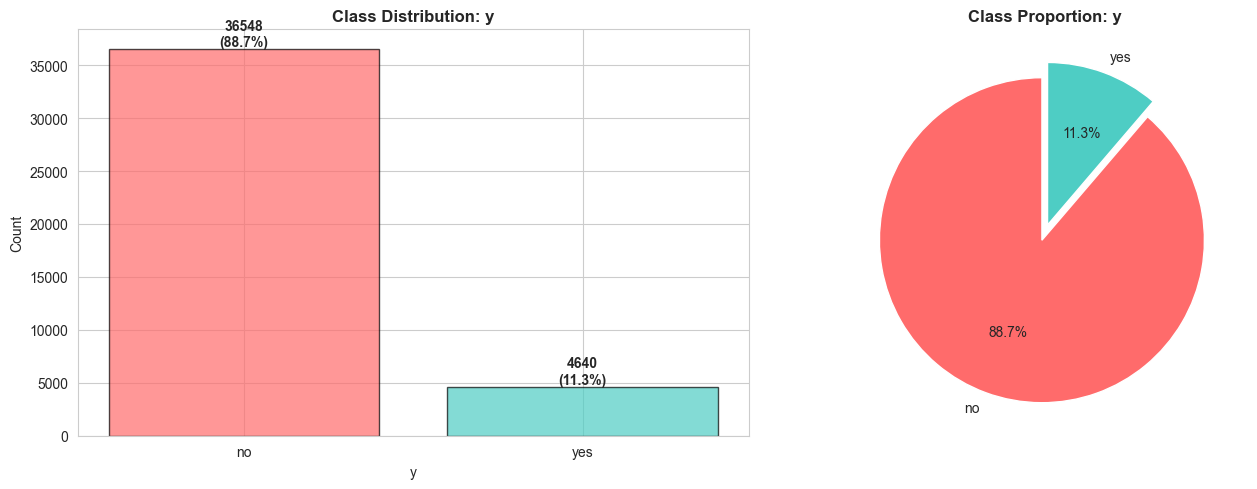

In [16]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
value_counts = target_data.value_counts().sort_index()
axes[0].bar(range(len(value_counts)), value_counts.values, 
            color=['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(value_counts)], 
            alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(value_counts)))
axes[0].set_xticklabels(value_counts.index)
axes[0].set_title(f'Class Distribution: {target_column}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel(target_column)

# Add count labels on bars
for i, (idx, count) in enumerate(value_counts.items()):
    axes[0].text(i, count, f'{count}\n({class_proportions.iloc[i]*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%',
           colors=['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(value_counts)],
           startangle=90, explode=[0.05]*len(value_counts))
axes[1].set_title(f'Class Proportion: {target_column}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Handle class Imbalance for Logistic Regression

### Why Class Imbalance is a Problem:

With a **7.88:1 ratio** (89% "no" vs 11% "yes"), we have a significant imbalance issue.

We could have a model that predicts "no" for every customer and still achieve 89% accuracy, but it would fail to identify any "yes" customers (0% recall for the minority class). This is why we need to use techniques that address class imbalance to improve our model's ability to predict the minority class ("yes") effectively.

Solutions to handle class imbalance include:
- SOLUTION 1: CLASS WEIGHTS 
   The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies:
      weight_no = n_samples / (n_classes * n_samples_no)
      weight_yes = n_samples / (n_classes * n_samples_yes)
   For your data:
      weight_no  ≈ 41188 / (2 * 36548) ≈ 0.56
      weight_yes ≈ 41188 / (2 * 4640)  ≈ 4.44
   Result: "yes" errors cost ~8x more than "no" errors!

- SOLUTION 2: SMOTE (Use if class_weight is not enough)
   CRITICAL: Do NOT apply SMOTE to test data!
   Test data must represent real-world distribution (89% no, 11% yes)

- SOLUTION 3: COMBINE CLASS WEIGHTS + SMOTE (Most powerful)
- SOLUTION 4: THRESHOLD ADJUSTMENT (Fine-tuning)
   Choose threshold based on business needs:
   - High precision: Fewer false positives (don't waste calls on "no" customers)
   - High recall: Catch more "yes" customers (don't miss potential subscribers)
   - Balanced: Use F1-score




### Feature-Target Relationship Analysis

For Logistic Regression, we want to see **how well features separate the classes**.

In [17]:
# For numeric features: Analyze distribution by class
if numeric_features:
    print("="*70)
    print("NUMERIC FEATURES: CLASS SEPARATION ANALYSIS")
    print("="*70)
    
    for feature in numeric_features:
        print(f"\n{feature}:")
        print(df.groupby(target_column)[feature].describe().T)

NUMERIC FEATURES: CLASS SEPARATION ANALYSIS

age:
y           no     yes
count 36548.00 4640.00
mean     39.91   40.91
std       9.90   13.84
min      17.00   17.00
25%      32.00   31.00
50%      38.00   37.00
75%      47.00   50.00
max      95.00   98.00

duration:
y           no     yes
count 36548.00 4640.00
mean    220.84  553.19
std     207.10  401.17
min       0.00   37.00
25%      95.00  253.00
50%     163.50  449.00
75%     279.00  741.25
max    4918.00 4199.00

campaign:
y           no     yes
count 36548.00 4640.00
mean      2.63    2.05
std       2.87    1.67
min       1.00    1.00
25%       1.00    1.00
50%       2.00    2.00
75%       3.00    2.00
max      56.00   23.00

pdays:
y           no     yes
count 36548.00 4640.00
mean    984.11  792.04
std     120.66  403.41
min       0.00    0.00
25%     999.00  999.00
50%     999.00  999.00
75%     999.00  999.00
max     999.00  999.00

previous:
y           no     yes
count 36548.00 4640.00
mean      0.13    0.49
std       0.

### Visualize numeric features by class (Box plots & Violin plots)

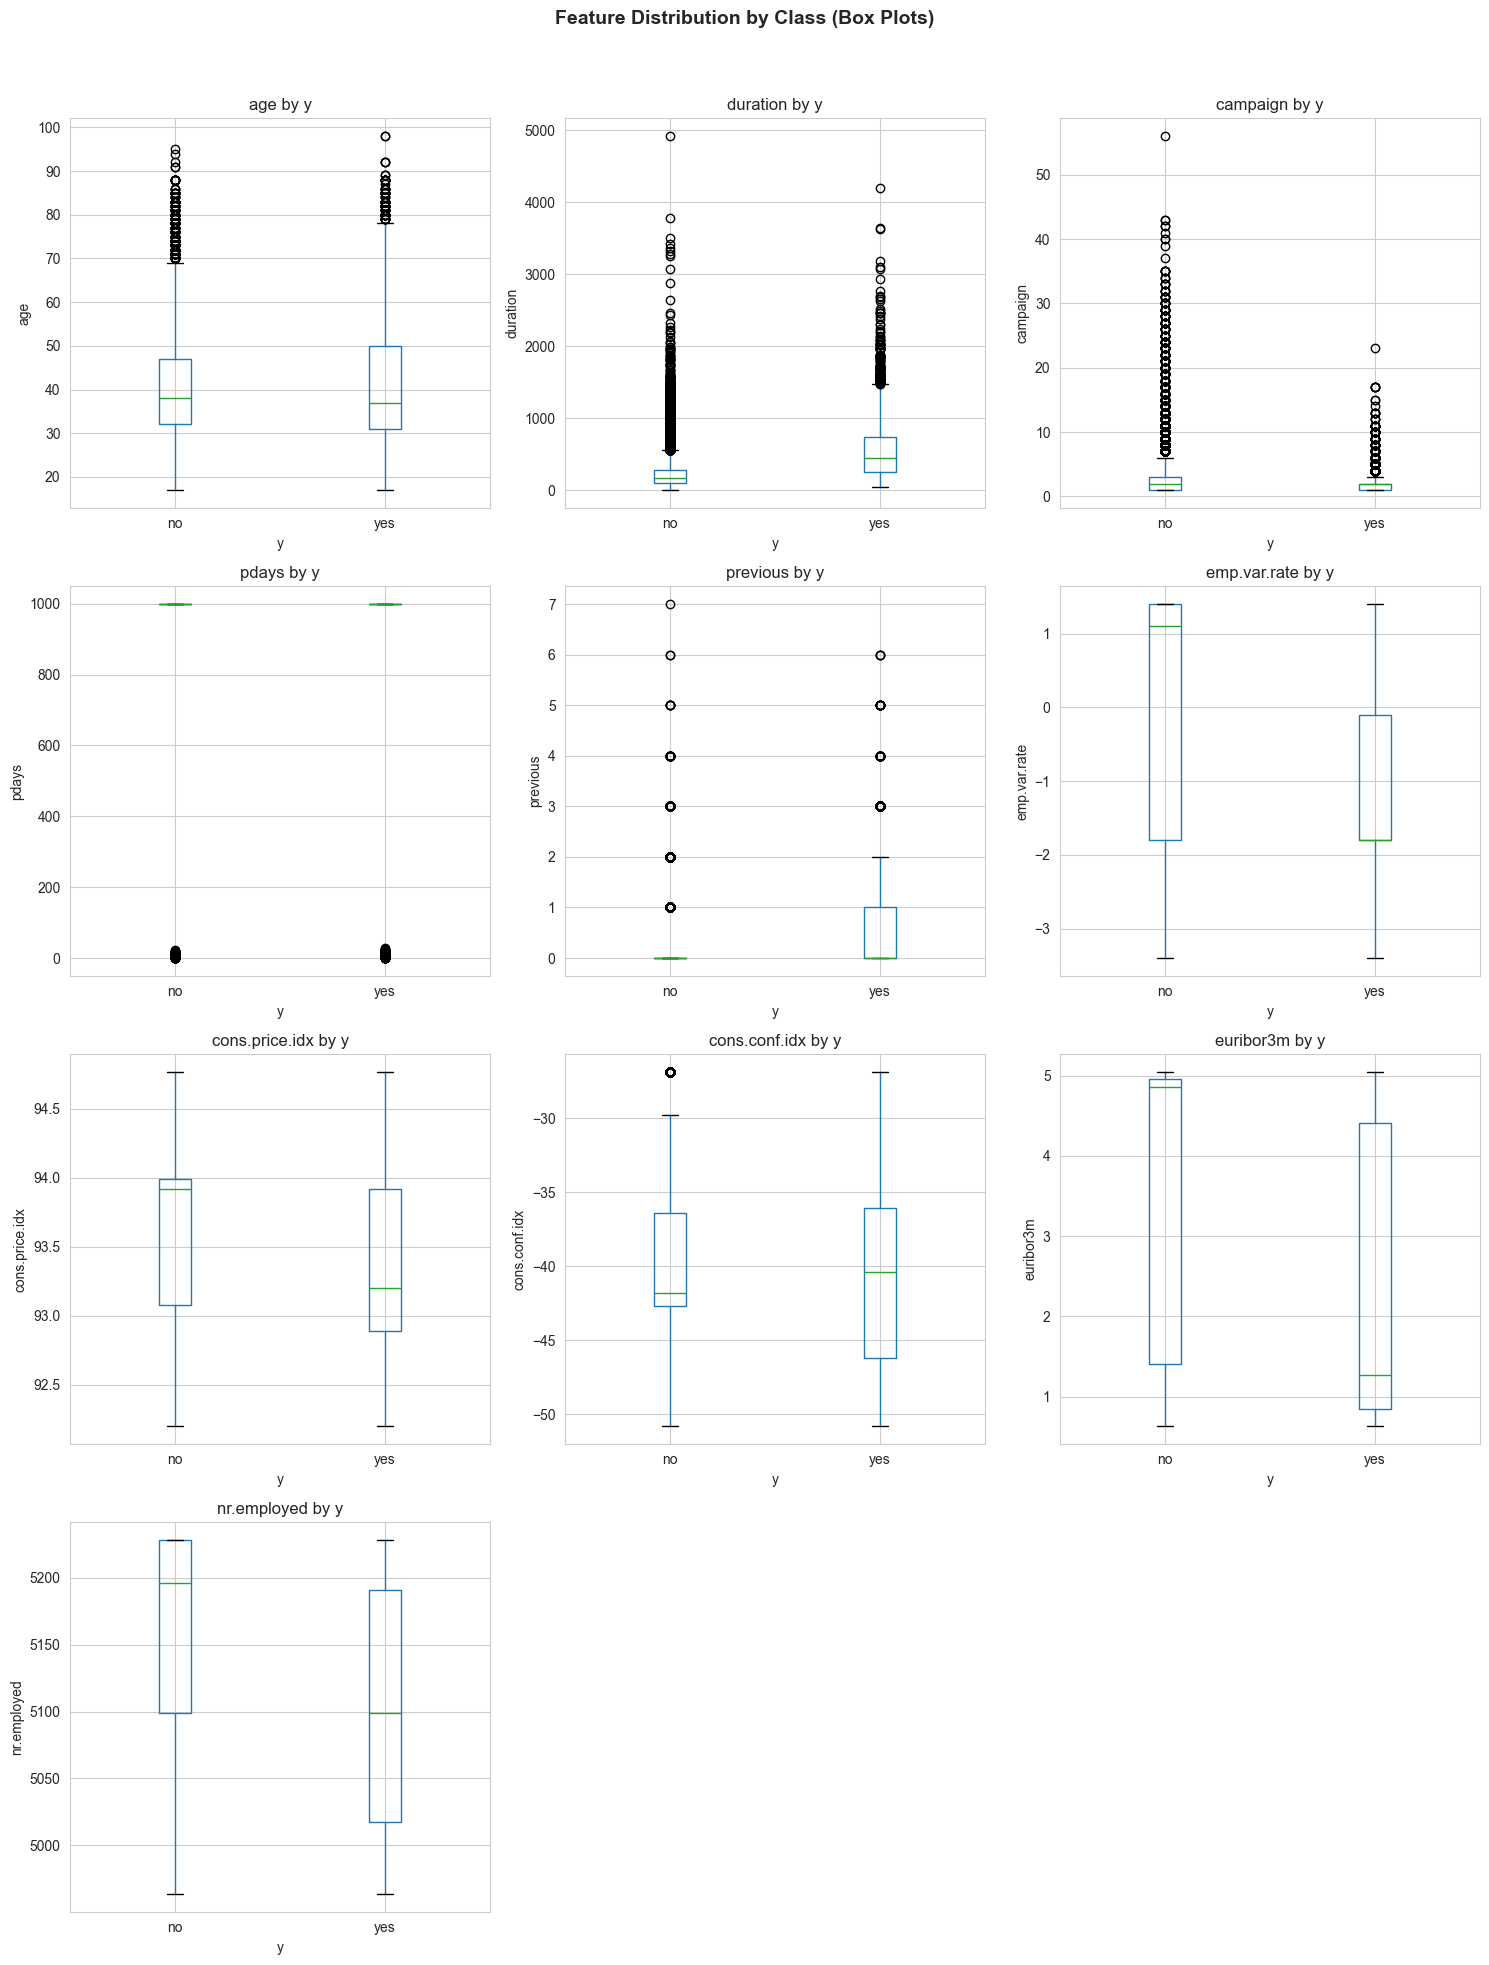

In [18]:
# Visualize numeric features by class (Box plots & Violin plots)
if numeric_features:
    n_features = len(numeric_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, feature in enumerate(numeric_features):
        # Box plot by class
        df.boxplot(column=feature, by=target_column, ax=axes[idx])
        axes[idx].set_title(f'{feature} by {target_column}')
        axes[idx].set_xlabel(target_column)
        axes[idx].set_ylabel(feature)
        plt.sca(axes[idx])
    
    # Hide empty subplots
    for idx in range(len(numeric_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Feature Distribution by Class (Box Plots)', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#### Clearly Separated, strong variables:

* duration: Very clear separation! "Yes" class has much higher duration values. This is likely your strongest predictor - longer call duration correlates with signing up.

* pdays: Clear difference - "yes" class has lower values, suggesting recent contact matters.

* euribor3m: Good separation - economic indicator that differs between classes.

* nr.employed: Shows separation - employment rate affects decisions.

#### Moderate Separation (Moderate Predictors)

* age: Slight difference in medians - some predictive power but overlapping distributions.

* campaign: Small separation - number of contacts during campaign has some effect.

* emp.var.rate: Moderate separation in economic indicator.

#### Poor Separation (Weak Predictors)

*previous: Almost identical distributions - might not add much value.

*cons.price.idx and cons.conf.idx: Very similar boxes - limited discrimination power.

#### Conclusions
* Duration is critical: Customers who spend more time on calls are more likely to subscribe (but be careful - duration is known only after the call).

* Recent contact matters: Lower pdays values for "yes" class means following up soon after previous contact helps.

* Economic factors: euribor3m and nr.employed show economic conditions influence decisions.

* Age has minor effect: Slightly different distributions suggest age plays a small role.

### Columns to consider for modeling based on separation:
* **Columns to keep:** duration, euribor3m, nr.employed, pdays

* **Columns to consider if there are necessary:** age, campaign, emp.var.rate

* **Columns to remove:** previous, cons.price.idx, cons.conf.idx (may remove if adding little value)

### Violin plots for better visualization of distributions

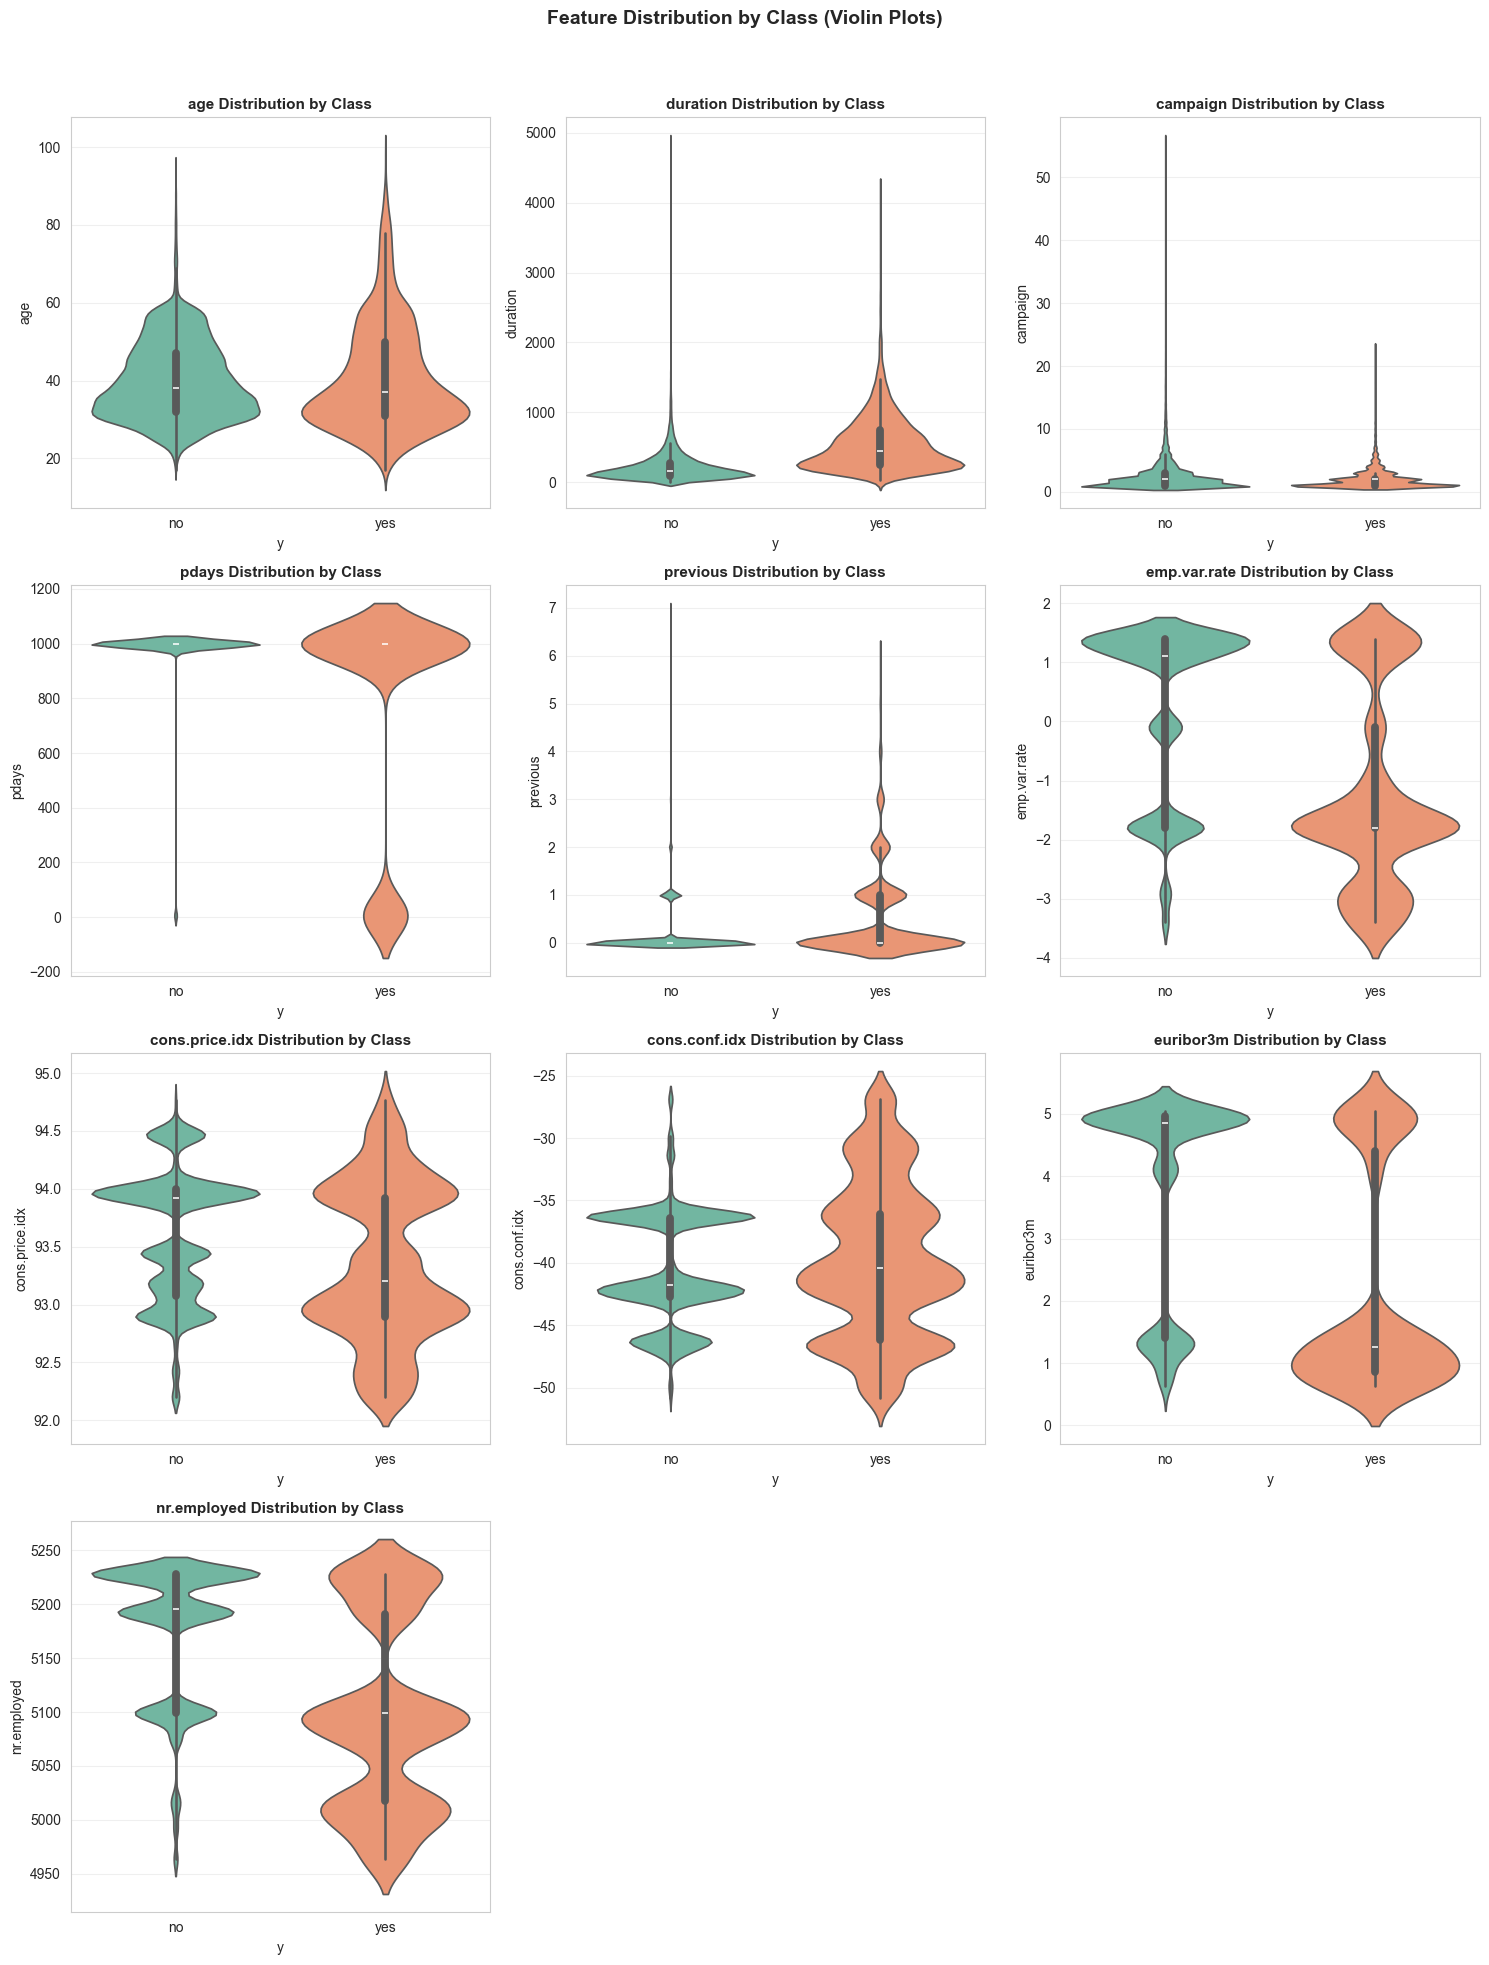

In [19]:
# Violin plots for better visualization of distributions
if numeric_features:
    n_features = len(numeric_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, feature in enumerate(numeric_features):
        sns.violinplot(data=df, x=target_column, y=feature, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'{feature} Distribution by Class', fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Hide empty subplots
    for idx in range(len(numeric_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Feature Distribution by Class (Violin Plots)', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#### Excellent Predictors (Clear Separation)
1. duration (Call Duration)

* "Yes" class: Wide distribution extending to very high values (up to 5000+)
* "No" class: Narrow, concentrated at low values (mostly under 500)
* Interpretation: Customers who subscribe spend significantly more time on calls. This is your strongest predictor!
Duration is only known after the call ends, so it can't be used for real-time prediction during calls.

2. pdays (Days Since Last Contact)

* "Yes" class: Concentrated at lower values with a diamond-shaped bulge
* "No" class: Different distribution pattern, more spread
Interpretation: Recent contact (lower pdays) correlates with signing up. Follow-up timing matters!

3. euribor3m (Euribor 3-month Rate)

* Clear positional difference between classes
* "No" and "Yes" violins are positioned at different economic indicator values
* Interpretation: Economic conditions significantly influence customer decisions.

4. nr.employed (Number of Employees)

* Multiple distinct peaks in both classes but at different positions
* Shows a bimodal distribution (two bulges)
* Interpretation: Employment indicators matter. The different peak positions suggest different economic scenarios favor different outcomes.


#### Moderate Predictors (Some Separation)

5. emp.var.rate (Employment Variation Rate)

* Different shapes between classes but with some overlap
* "Yes" class: More spread out (wider violin)
* "No" class: More concentrated
* Interpretation: Employment variation has some predictive power but not as strong as other economic indicators.

6. age

* Similar bell-shaped distributions for both classes
* Slight difference in median positions
* Interpretation: Age plays a minor role. Both classes span similar age ranges with only subtle differences.


#### Weak Predictors (Poor Separation)

7. campaign (Number of Contacts)

* Nearly identical distributions for both classes
* Both heavily concentrated near zero with long thin tails
Interpretation: Number of contacts during this campaign doesn't strongly differentiate outcomes.

8. previous (Number of Previous Contacts)

* Extremely similar violin shapes
* Both concentrated at very low values (near 0)
* Interpretation: Previous contact history adds little predictive value. Consider removing.

9. cons.price.idx (Consumer Price Index)

* Multimodal (3-4 distinct bulges in each violin)
* Similar patterns in both classes
* Interpretation: Consumer price levels don't clearly separate classes. The multiple peaks suggest this might benefit from binning into categories.

10. cons.conf.idx (Consumer Confidence Index)

* Multiple horizontal bulges indicating several concentration points
* Very similar shapes between classes
* Interpretation: Consumer confidence doesn't discriminate well between classes. Consider removing or feature engineering.

#### Key Insights from Distribution Shapes

Multimodal Features (Multiple Bulges):

* nr.employed, cons.price.idx, cons.conf.idx show multiple peaks

* This suggests these features might represent distinct categories or time periods

* Action: Consider binning these into categorical groups

Skewed Features:

* duration, campaign, previous are heavily right-skewed (long tail to the right)
* Action: Consider log transformation for modeling

Symmetric Features:
* age appears relatively normally distributed

* Action: No transformation needed

### Conclusions depending on the violin plots
* **Columns to keep:** duration, euribor3m, nr.employed, pdays

* **Columns to consider:** age, emp.var.rate

* **Columns to remove:** campaign, previous, cons.price.idx, cons.conf.idx (may remove if adding little value)


### Overlapping histograms for class comparison

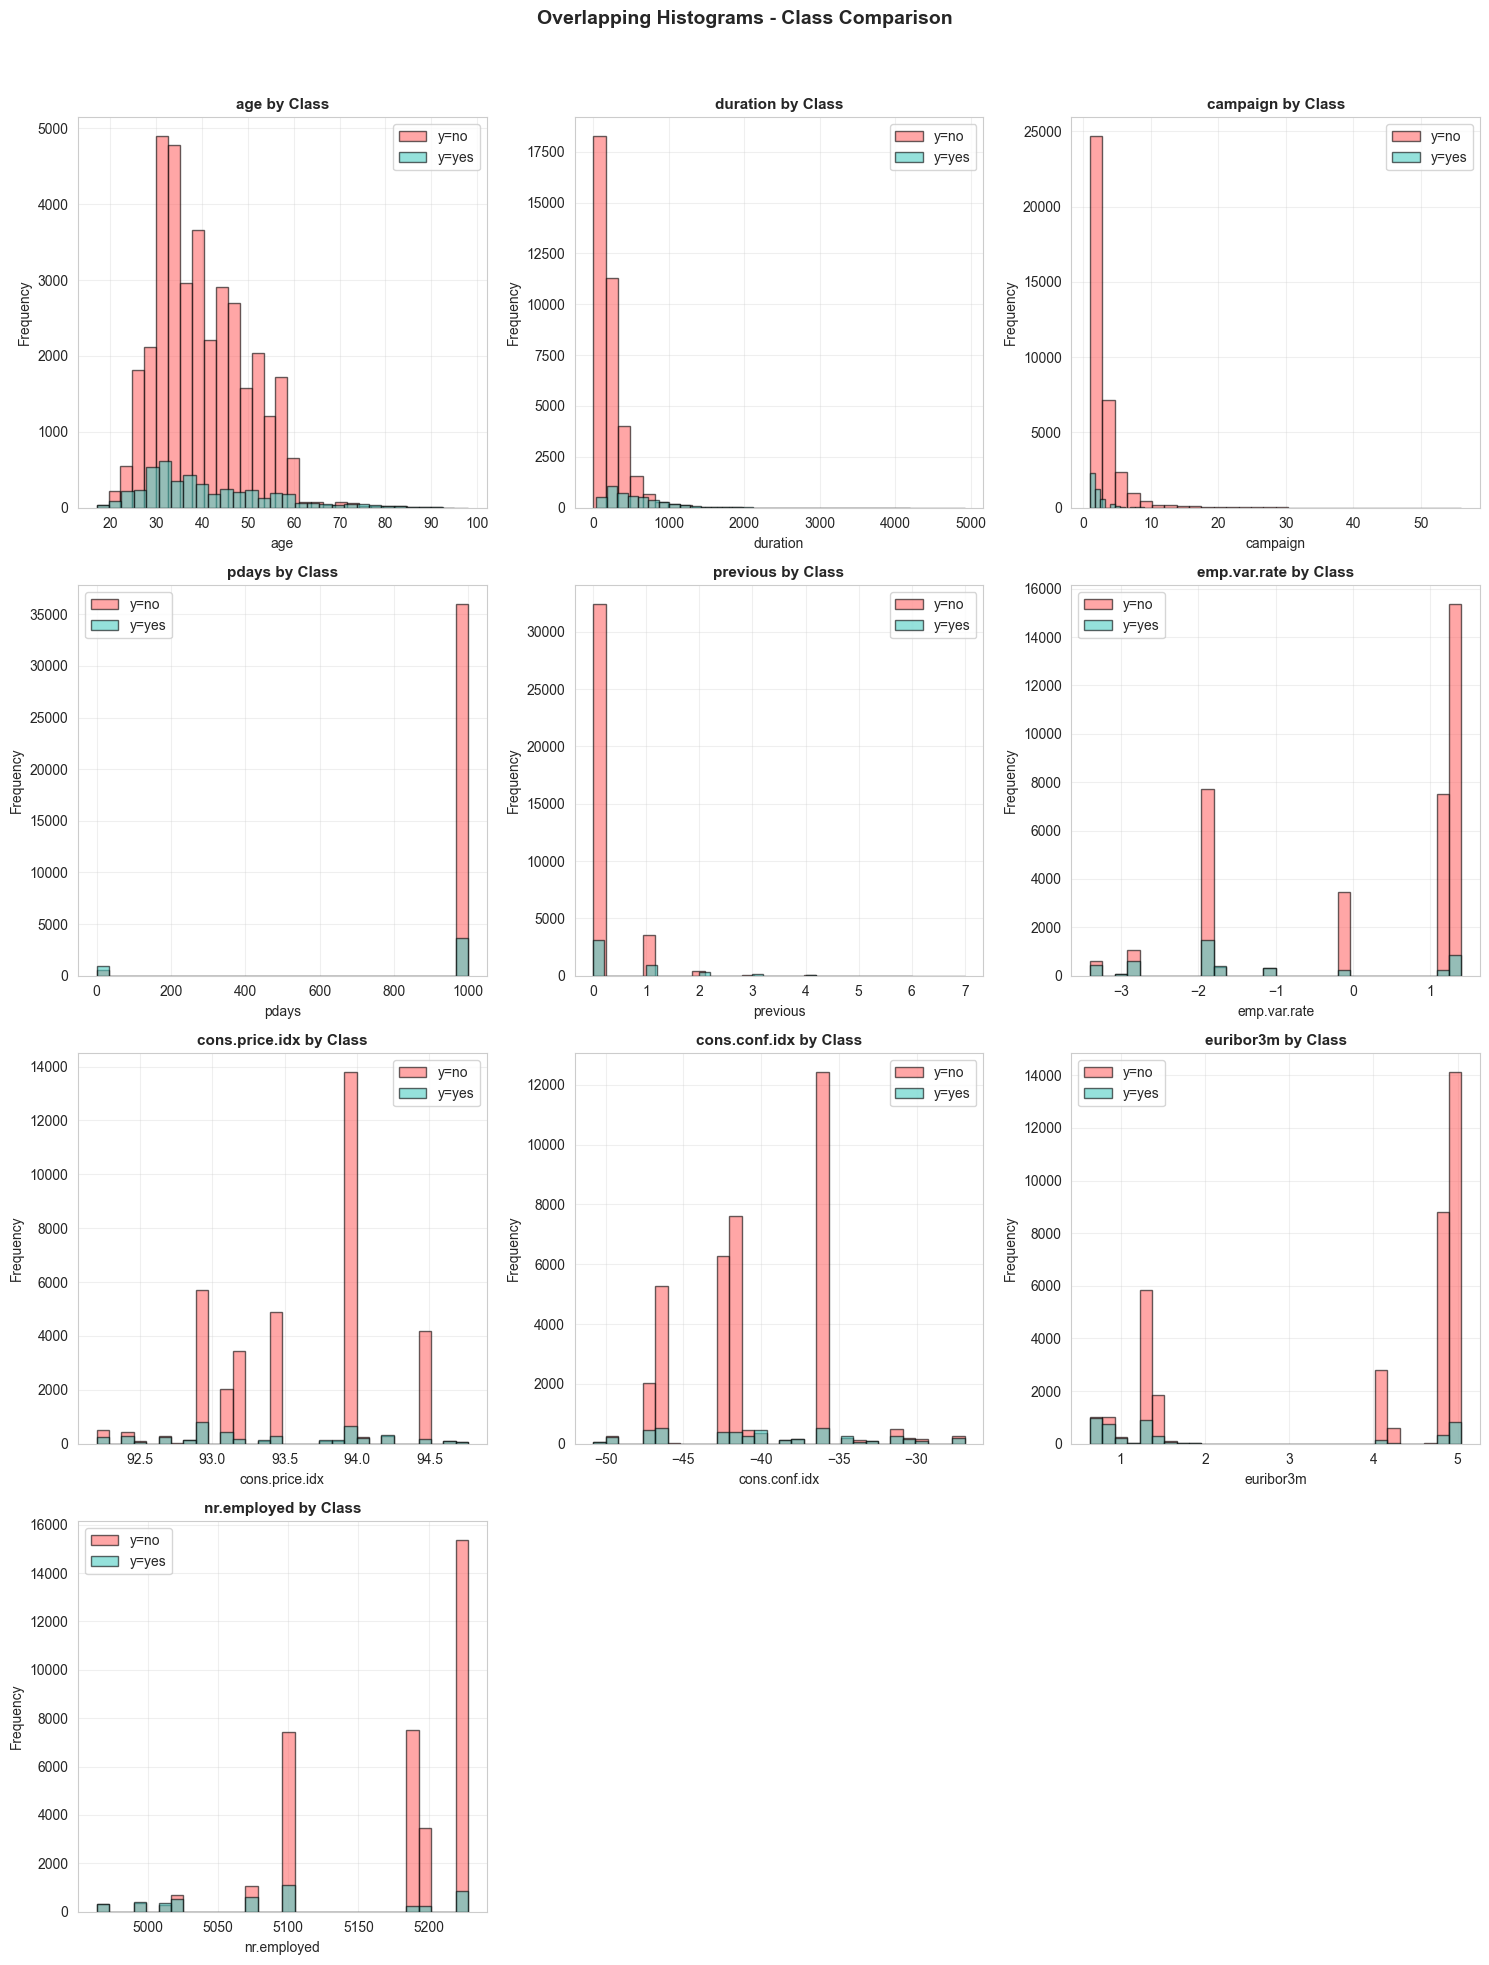

In [20]:
# Overlapping histograms for class comparison
if numeric_features:
    n_features = len(numeric_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    classes = df[target_column].unique()
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3']
    
    for idx, feature in enumerate(numeric_features):
        for i, cls in enumerate(classes):
            class_data = df[df[target_column] == cls][feature].dropna()
            axes[idx].hist(class_data, bins=30, alpha=0.6, 
                          label=f'{target_column}={cls}', 
                          color=colors[i % len(colors)],
                          edgecolor='black')
        
        axes[idx].set_title(f'{feature} by Class', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(numeric_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Overlapping Histograms - Class Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#### Overlapping Histograms 
These overlapping histograms show the frequency distribution of each feature for both classes (red = "no", teal = "yes"), making it easy to see where the two classes overlap or separate.

* Red bars (y=no): Distribution of customers who did NOT subscribe
* Teal bars (y=yes): Distribution of customers who DID subscribe
* Overlapping areas: Where both classes have similar values (bad for prediction)
* Separated areas: Where one class dominates (good for prediction!)

#### Feature-by-Feature Analysis

1. age - Weak Separator

* Both distributions heavily overlap with similar bell-shaped curves

* Peak around 30-40 years for both classes

* Interpretation: Age alone doesn't strongly distinguish subscribers from non-subscribers

* **Usefulness**: Low 

2. duration - good separator

* Red (no): Massive spike near 0, very few long calls

* Teal (yes): More spread out, extends to much longer durations (1000-5000+)

* Very little overlap at higher durations

* Interpretation: Long call duration STRONGLY predicts subscription! Customers who engage longer are far more likely to sign up.

* **Usefulness**: High (good predictor!)

* Head up : Only known after call ends

3. campaign - Very Weak Separator

* Both distributions: Extremely concentrated at low values (1-5 contacts)

* Almost identical patterns - both spike at the same point

* Interpretation: Number of contacts during current campaign doesn't differentiate

* **Usefulness**: Low 

4. pdays - Strong Separator 

* Red (no): Huge spike at high value (999 = never contacted)

* Teal (yes): More concentrated at lower values (recent contact)

* Clear separation between recent vs. no previous contact

* Interpretation: Customers contacted recently (lower pdays) are MORE likely to subscribe!

* **Usefulness**: High

5. previous - Weak Separator
* Both distributions: Heavily concentrated at 0 (no previous contacts)

* Nearly identical spikes at the same positions

* Interpretation: Previous contact count adds minimal predictive value

* **Usefulness**: Low 

6. emp.var.rate - Moderate Separator
* Different peak positions between classes

* Teal (yes): Multiple peaks at different values than red

* Red (no): Different concentration points

* Interpretation: Employment variation rate has some discriminatory power related to economic conditions

* **Usefulness** : Moderate

7. cons.price.idx - Weak Separator

* Multiple peaks for both classes (multimodal distribution)

* Very similar patterns between red and teal

* Heavy overlap at all price index levels

* Interpretation: Consumer price index doesn't distinguish classes well

* **Usefulness**: Low 


8. cons.conf.idx - Weak Separator

* Multiple distinct peaks (at -50, -45, -40, -35 approximately)

* Both classes show similar multimodal patterns

* Heavy overlap at each peak

* Interpretation: Consumer confidence levels are similar for both groups

* **Usefulness**: Low 


9. euribor3m - Strong Separator
* Different concentration zones

* Red (no): Multiple peaks across range

* Teal (yes): Concentrated at different euribor values

* Some separation visible between peak positions

* Interpretation: Economic indicator (3-month euribor rate) influences subscription behavior

* **Usefulness**: High


10. nr.employed - Strong Separator

* Clear different peaks between classes

* Teal (yes): Strong peaks at specific employment numbers

* Red (no): Different peak positions

* Multiple distinct clusters suggesting different time periods/economic conditions

* Interpretation: Number of employees (economic indicator) strongly relates to subscription likelihood

* **Usefulness**: High

#### Key Visual Patterns to Look For

* Good Separators (Useful for prediction):
1 - Non-overlapping peaks: One color dominates in certain ranges
2 - Different shapes: One class concentrated, other spread out
3 - Shifted distributions: Peaks at different x-values
* Poor Separators (Not useful):
1 - Identical peaks: Both colors spike at same values
2 - Complete overlap: Can't see one color because other covers it
3 - Same spread: Both distributions have similar range and shape

### Conclusions depending on the overlapping histograms
* **Columns to keep:** duration, euribor3m, nr.employed, pdays

* **Columns to consider:** age, emp.var.rate

* **Columns to remove:** campaign, previous, cons.price.idx, cons.conf.idx (may remove if adding little value)

#### Business insights from the visualizations
* Duration is a critical predictor: Customers who spend more time on calls are much more likely to subscribe. This suggests that engaging customers in longer conversations can increase conversion rates.  
* Recent contact matters: Customers contacted recently (lower pdays) are more likely to subscribe. This highlights the importance of timely follow-ups in marketing campaigns.
* Economic conditions influence decisions: Both euribor3m and nr.employed show that economic indicators play a significant role in customer behavior. The bank should monitor these indicators to optimize campaign timing.
* Age has a minor effect: While age shows some differences, it is not a strong predictor. The bank may want to focus less on age and more on behavioral and economic factors when targeting customers.  
* Campagin intensity and previous contact history add little value: The number of contacts during the campaign and previous contact count do not differentiate well between subscribers and non-subscribers. The bank may want to reconsider the emphasis on these factors in their marketing strategy.
* Consumer price and confidence indices are not strong predictors: These economic indicators do not show clear separation between classes, suggesting they may not be useful for targeting customers. The bank could consider removing these features or engineering new ones based on them.


## Categorical Features Analysis

Analyze categorical variables and their relationship with the target using:
- **Chi-square test** for independence
- **Stacked bar charts** for visual comparison

In [21]:
# Categorical features summary
if categorical_features:
    print("="*70)
    print("CATEGORICAL FEATURES SUMMARY")
    print("="*70)
    for col in categorical_features:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Value counts:") 
        print(f"  {df[col].value_counts()}")
else:
    print("x No categorical features in the dataset.")

CATEGORICAL FEATURES SUMMARY

job:
  Unique values: 12
  Value counts:
  job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital:
  Unique values: 4
  Value counts:
  marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education:
  Unique values: 8
  Value counts:
  education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default:
  Unique values: 3
  Value counts:
  default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing:
  Unique 

### Chi-square test for categorical features

In [22]:
# Chi-square test for categorical features
if categorical_features:
    print("="*70)
    print("CHI-SQUARE TEST: Categorical Features vs Target")
    print("="*70)
    print("Tests if categorical features are independent of the target variable.")
    print("p-value < 0.05: Feature is significantly related to target ✓")
    print("p-value >= 0.05: Feature is independent of target ✗")
    print("-"*70)
    
    chi_square_results = []
    
    for feature in categorical_features:
        # Create contingency table
        contingency_table = pd.crosstab(df[feature], df[target_column])
        
        # Perform chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        chi_square_results.append({
            'Feature': feature,
            'Chi-Square': chi2,
            'p-value': p_value,
            'Significant': '✓' if p_value < 0.05 else '✗'
        })
        
        print(f"\n{feature}:")
        print(f"  Chi-Square: {chi2:.4f}")
        print(f"  p-value: {p_value:.4f}")
        print(f"  Significant: {chi_square_results[-1]['Significant']}")
    
    # Summary table
    print("\n" + "="*70)
    chi_df = pd.DataFrame(chi_square_results)
    display(chi_df)

CHI-SQUARE TEST: Categorical Features vs Target
Tests if categorical features are independent of the target variable.
p-value < 0.05: Feature is significantly related to target ✓
p-value >= 0.05: Feature is independent of target ✗
----------------------------------------------------------------------

job:
  Chi-Square: 961.2424
  p-value: 0.0000
  Significant: ✓

marital:
  Chi-Square: 122.6552
  p-value: 0.0000
  Significant: ✓

education:
  Chi-Square: 193.1059
  p-value: 0.0000
  Significant: ✓

default:
  Chi-Square: 406.5775
  p-value: 0.0000
  Significant: ✓

housing:
  Chi-Square: 5.6845
  p-value: 0.0583
  Significant: ✗

loan:
  Chi-Square: 1.0940
  p-value: 0.5787
  Significant: ✗

contact:
  Chi-Square: 862.3184
  p-value: 0.0000
  Significant: ✓

month:
  Chi-Square: 3101.1494
  p-value: 0.0000
  Significant: ✓

day_of_week:
  Chi-Square: 26.1449
  p-value: 0.0000
  Significant: ✓

poutcome:
  Chi-Square: 4230.5238
  p-value: 0.0000
  Significant: ✓



,Feature,Chi-Square,p-value,Significant
0,job,961.24,0.00,✓
1,marital,122.66,0.00,✓
2,education,193.11,0.00,✓
3,default,406.58,0.00,✓
4,housing,5.68,0.06,✗
5,loan,1.09,0.58,✗
6,contact,862.32,0.00,✓
7,month,3101.15,0.00,✓
8,day_of_week,26.14,0.00,✓
9,poutcome,4230.52,0.00,✓


#### Conclusions from Chi-Square Test Results (χ² = Σ [(Observed - Expected)² / Expected])

Ranked by Chi-Square Value (strength of relationship):

- STRONGLY SIGNIFICANT Features (Keep for modeling)
    1. poutcome (χ² = 4230.52) 
    * STRONGEST predictor among categorical features!
    * Previous campaign outcome is HIGHLY related to subscription
    * Insight: Past behavior predicts future behavior

    2. month (χ² = 3101.15)
    * Second strongest predictor
    * Timing of contact (which month) significantly affects success
    * Insight: Seasonality matters - some months are much better for campaigns

    3. job (χ² = 961.24) 
    * Strong relationship with subscription
    * Insight: Occupation type influences financial decisions

    4. contact (χ² = 862.32)
    * Contact method (cellular vs telephone) matters significantly
    * Insight: Communication channel affects conversion

    5. default (χ² = 406.58)
    * Credit default status relates to subscription
    * Insight: Credit history influences willingness to commit

    6. education (χ² = 193.11)
    * Education level affects subscription likelihood
    * Insight: Different education levels show different financial behaviors

    7. marital (χ² = 122.66) 
    * Marital status has moderate relationship
    * Insight: Family situation influences financial decisions

    8. day_of_week (χ² = 26.14) 
    * Weakest significant feature, but still related
    * Insight: Day of week has small but measurable effect

- NOT SIGNIFICANT Features (Consider removing)
9. housing (χ² = 5.68, p = 0.0583)
* Borderline - very close to significance (p = 0.058 vs. 0.05 threshold)
* Decision: Could keep and let model decide, or remove for simplicity
* Insight: Having a housing loan is almost unrelated to subscription

10. loan (χ² = 1.09, p = 0.5787) 
* Clearly NOT significant
* Personal loan status is independent of subscription
* Strong recommendation: Remove this feature
* Insight: Personal loan status doesn't predict subscription behavior

#### Conculsions based on the chi-square test results

Keep These Features:
* Columns to keep: poutcome, month, job, contact, default, education, marital, day_of_week

* Columns to consider: housing

* Columns to remove: loan



### Visualize categorical features

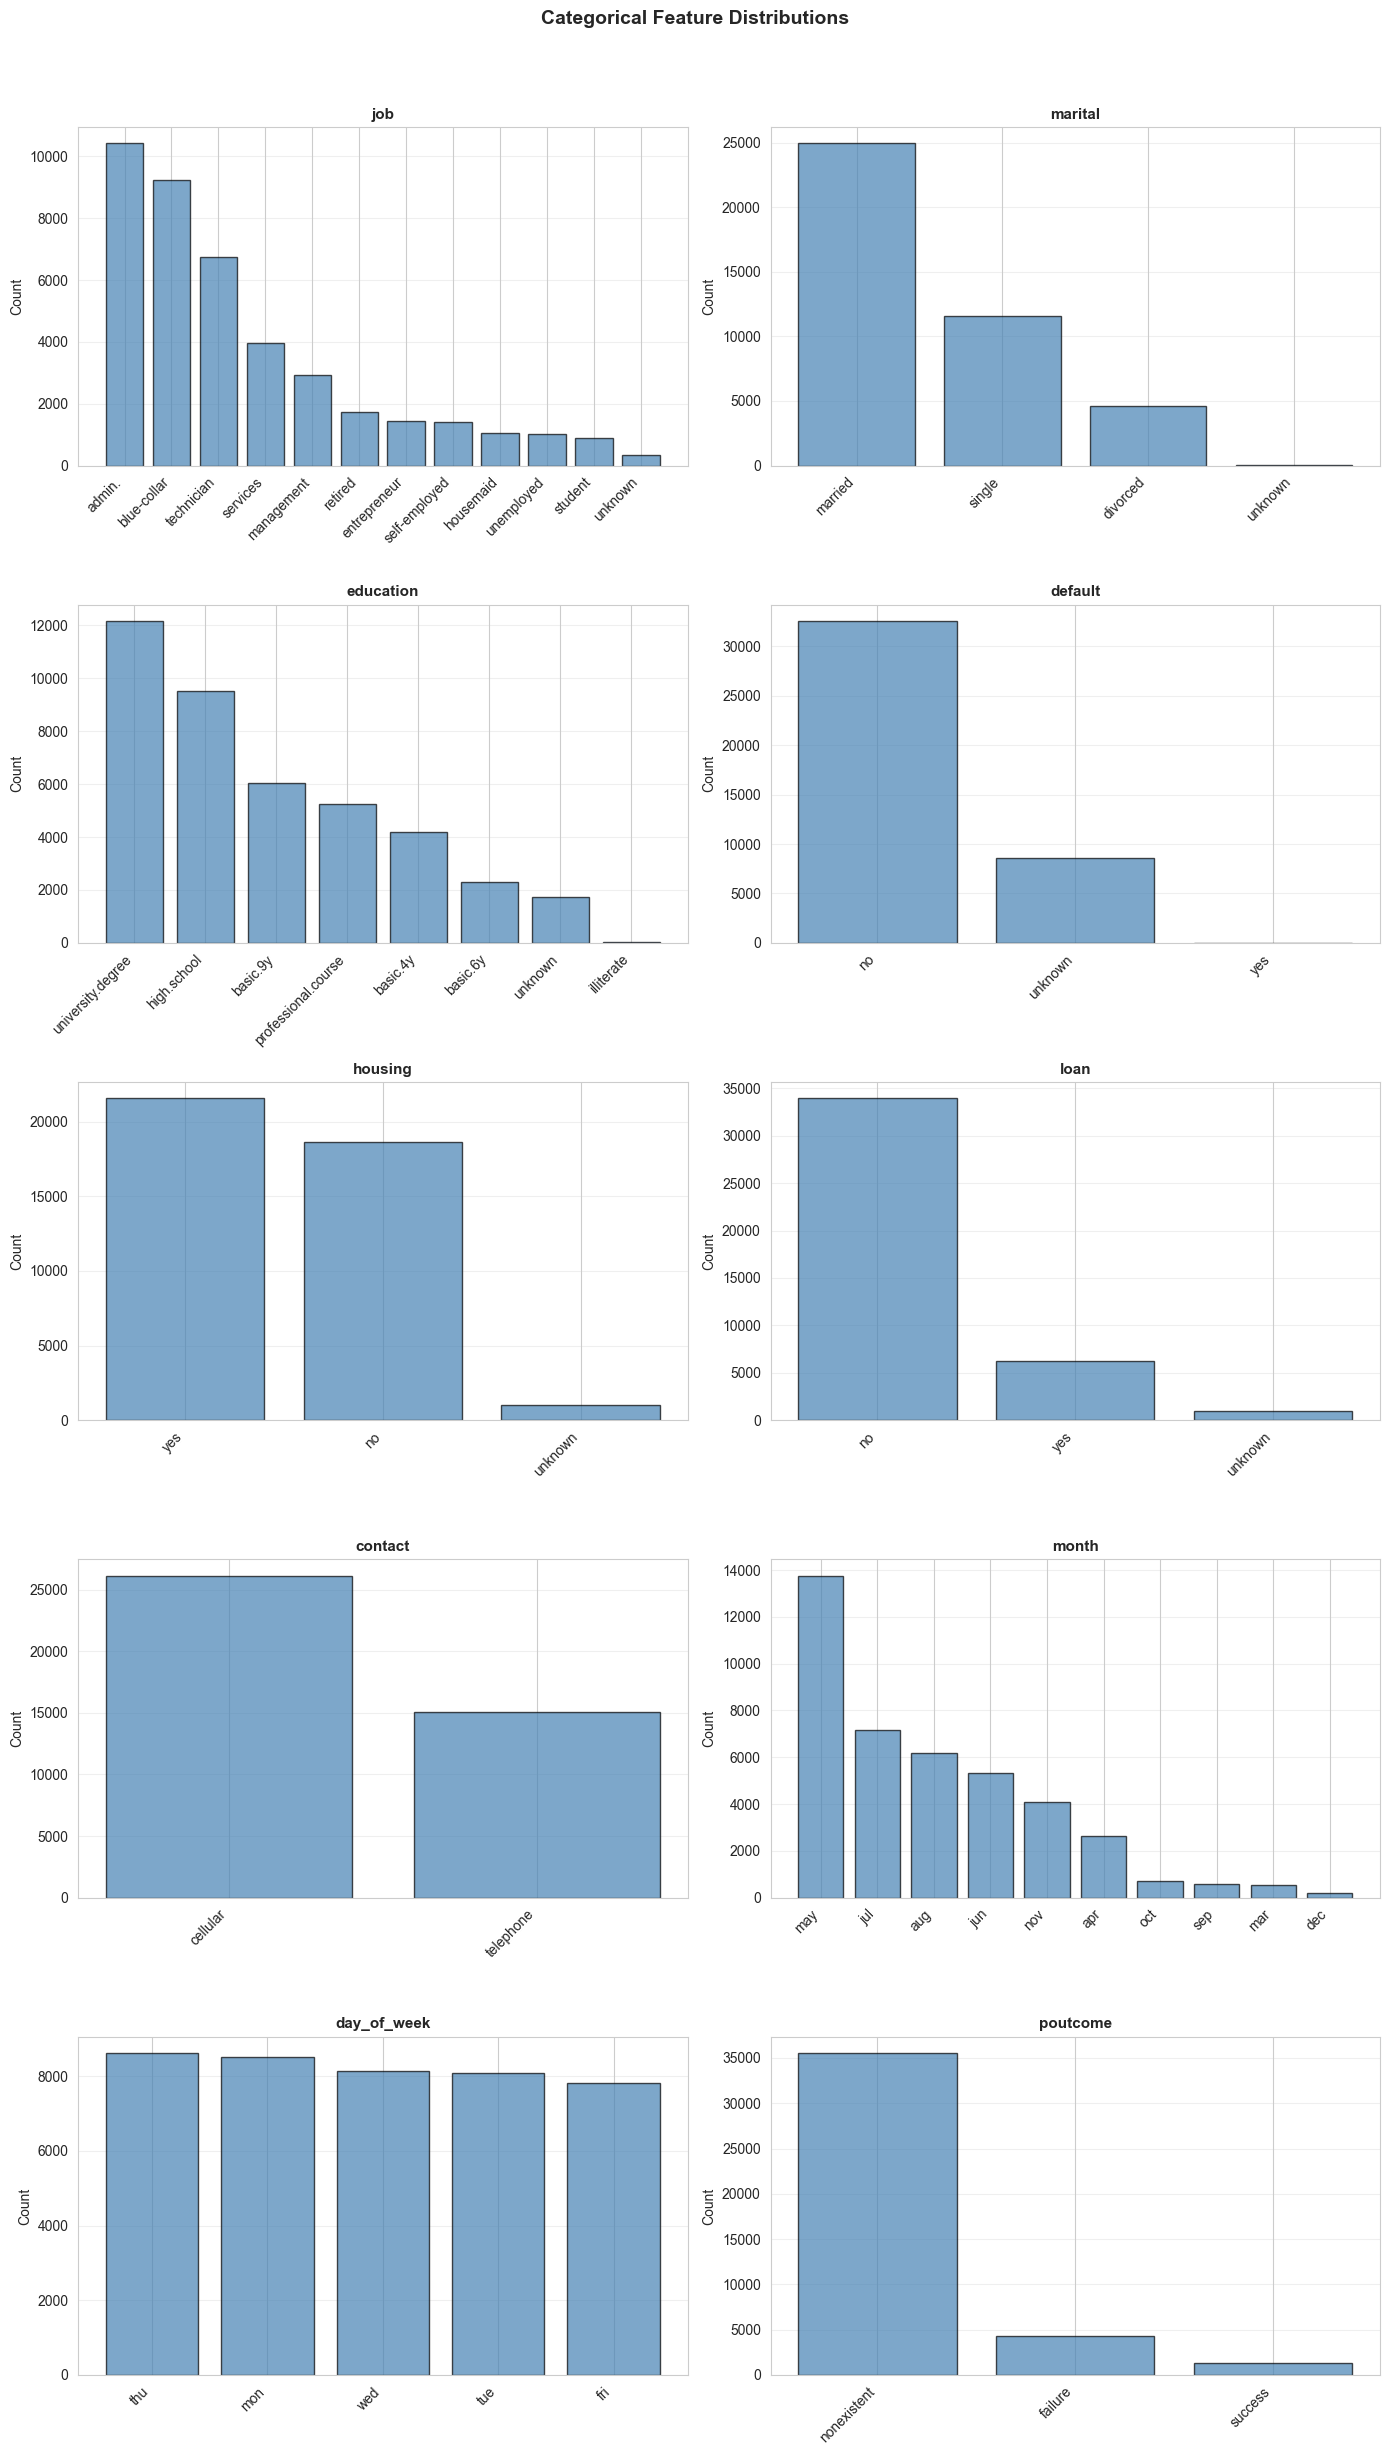

In [23]:
# Visualize categorical features
if categorical_features:
    n_features = len(categorical_features)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(categorical_features):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, 
                     color='steelblue', alpha=0.7, edgecolor='black')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Hide empty subplots
    for idx in range(len(categorical_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### Rare Category Detection

Rare categories (those with very low frequency) can cause problems:
- May not appear in both train/test sets after splitting
- Can lead to model instability
- May need to be grouped or handled specially

**Threshold:** Categories with < 5% of total observations are considered rare.

In [24]:
# Detect rare categories (< 5% of total observations)
if categorical_features:
    print("="*80)
    print("RARE CATEGORY DETECTION")
    print("="*80)
    print(f"Threshold: Categories with < 5% ({len(df) * 0.05:.0f} observations) are flagged as rare\n")
    
    rare_category_analysis = []
    
    for feature in categorical_features:
        value_counts = df[feature].value_counts()
        value_percentages = (value_counts / len(df)) * 100
        
        # Find rare categories
        rare_categories = value_percentages[value_percentages < 5]
        
        if len(rare_categories) > 0:
            print(f"\n{feature}:")
            print(f"  Total categories: {df[feature].nunique()}")
            print(f"  Rare categories: {len(rare_categories)}")
            print(f"  Rare category details:")
            
            for cat, pct in rare_categories.items():
                count = value_counts[cat]
                print(f"    • {cat:25} → {count:5} obs ({pct:5.2f}%)")
                
            rare_category_analysis.append({
                'Feature': feature,
                'Total_Categories': df[feature].nunique(),
                'Rare_Categories': len(rare_categories),
                'Rare_Category_Names': list(rare_categories.index)
            })
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY AND RECOMMENDATIONS")
    print("="*80)
    
    if rare_category_analysis:
        print(f"\n⚠ {len(rare_category_analysis)} feature(s) have rare categories:\n")
        
        for item in rare_category_analysis:
            print(f"• {item['Feature']}: {item['Rare_Categories']} rare out of {item['Total_Categories']} total")
            print(f"  Rare categories: {', '.join(map(str, item['Rare_Category_Names']))}")
            print(f"  Actions:")
            
            if item['Total_Categories'] > 10:
                print(f"    - High cardinality! Consider grouping rare categories into 'Other'")
                print(f"    - Or use target encoding instead of one-hot encoding")
            elif item['Rare_Categories'] <= 3:
                print(f"    - Group rare categories: {', '.join(map(str, item['Rare_Category_Names']))} → 'other'")
            else:
                print(f"    - Review if these categories add predictive value")
                print(f"    - Consider grouping by similarity or business logic")
            print()
        
        print("\nNext Steps:")
        print("   1. Group rare categories using business/domain knowledge")
        print("   2. Example: df[feature].replace({'rare1': 'other', 'rare2': 'other'})")
        print("   3. Use stratified splitting to ensure representation in train/test")
        print("   4. For high-cardinality features: consider target encoding or frequency encoding")
        
    else:
        print("\n✓ No rare categories detected! All categories have sufficient representation.")
    
    print("\n" + "="*80)
else:
    print("No categorical features to analyze.")

RARE CATEGORY DETECTION
Threshold: Categories with < 5% (2059 observations) are flagged as rare


job:
  Total categories: 12
  Rare categories: 7
  Rare category details:
    • retired                   →  1720 obs ( 4.18%)
    • entrepreneur              →  1456 obs ( 3.54%)
    • self-employed             →  1421 obs ( 3.45%)
    • housemaid                 →  1060 obs ( 2.57%)
    • unemployed                →  1014 obs ( 2.46%)
    • student                   →   875 obs ( 2.12%)
    • unknown                   →   330 obs ( 0.80%)

marital:
  Total categories: 4
  Rare categories: 1
  Rare category details:
    • unknown                   →    80 obs ( 0.19%)

education:
  Total categories: 8
  Rare categories: 2
  Rare category details:
    • unknown                   →  1731 obs ( 4.20%)
    • illiterate                →    18 obs ( 0.04%)

default:
  Total categories: 3
  Rare categories: 1
  Rare category details:
    • yes                       →     3 obs ( 0.01%)

housing:

### Encoding Strategy Recommendations

Different encoding techniques for categorical variables:

1. **One-Hot Encoding** (Label Binarization)
   - Best for: Low cardinality features (< 10 categories)
   - Creates n-1 dummy variables
   - Most common for Logistic Regression

2. **Label Encoding** (Ordinal Encoding)
   - Best for: Ordinal features with natural order
   - Maps categories to integers (0, 1, 2, ...)
   - ⚠ Implies order - use carefully!

3. **Target Encoding** (Mean Encoding)
   - Best for: High cardinality features (> 10 categories)
   - Replaces category with mean of target for that category
   - Risk of overfitting - use with cross-validation

4. **Frequency Encoding**
   - Best for: When frequency matters
   - Replaces category with its frequency count or percentage
   - Preserves information about category importance

### Encoding strategy recommendations for each categorical feature

In [25]:
# Encoding strategy recommendations for each categorical feature
if categorical_features:
    print("="*80)
    print("ENCODING STRATEGY RECOMMENDATIONS")
    print("="*80)
    
    encoding_plan = []
    
    for feature in categorical_features:
        n_categories = df[feature].nunique()
        value_counts = df[feature].value_counts()
        max_freq_pct = (value_counts.iloc[0] / len(df)) * 100
        
        # Determine recommended encoding
        if n_categories == 2:
            encoding = "Label Encoding (Binary)"
            reason = "Binary feature - simple 0/1 encoding"
            code_example = f"df['{feature}'] = df['{feature}'].map({{'{value_counts.index[0]}': 0, '{value_counts.index[1]}': 1}})"
        
        elif n_categories <= 5:
            encoding = "One-Hot Encoding"
            reason = f"Low cardinality ({n_categories} categories) - creates {n_categories-1} features"
            code_example = f"pd.get_dummies(df['{feature}'], prefix='{feature}', drop_first=True)"
        
        elif n_categories <= 10:
            encoding = "One-Hot Encoding (with caution)"
            reason = f"Medium cardinality ({n_categories} categories) - creates {n_categories-1} features. Monitor dimensionality."
            code_example = f"pd.get_dummies(df['{feature}'], prefix='{feature}', drop_first=True)"
        
        else:
            encoding = "Target Encoding (preferred)"
            reason = f"High cardinality ({n_categories} categories) - one-hot would create too many features"
            code_example = f"# Use category_encoders.TargetEncoder or custom target encoding with CV"
        
        encoding_plan.append({
            'Feature': feature,
            'Categories': n_categories,
            'Recommended_Encoding': encoding,
            'Reason': reason,
            'Code_Example': code_example
        })
        
        print(f"\n{feature}:")
        print(f"  Cardinality: {n_categories} categories")
        print(f"  Dominant category: {value_counts.index[0]} ({max_freq_pct:.1f}%)")
        print(f"  ✓ Recommended: {encoding}")
        print(f"  Reason: {reason}")
        print(f"  Code: {code_example}")
    
    # Create summary DataFrame
    print("\n" + "="*80)
    print("ENCODING SUMMARY TABLE")
    print("="*80)
    
    encoding_df = pd.DataFrame(encoding_plan)[['Feature', 'Categories', 'Recommended_Encoding']]
    display(encoding_df)
    
    # Overall recommendations
    print("\n" + "="*80)
    print("IMPLEMENTATION PLAN")
    print("="*80)
    
    binary_features = [item['Feature'] for item in encoding_plan if item['Categories'] == 2]
    onehot_features = [item['Feature'] for item in encoding_plan if 'One-Hot' in item['Recommended_Encoding']]
    target_features = [item['Feature'] for item in encoding_plan if 'Target' in item['Recommended_Encoding']]
    
    print(f"\n1. Binary Features ({len(binary_features)}):")
    if binary_features:
        print(f"   Features: {', '.join(binary_features)}")
        print(f"   Method: LabelEncoder or manual mapping")
    else:
        print(f"   None")
    
    print(f"\n2. One-Hot Encoding ({len(onehot_features)}):")
    if onehot_features:
        print(f"   Features: {', '.join(onehot_features)}")
        print(f"   Method: pd.get_dummies() or OneHotEncoder")
        print(f"   Note: Creates {sum([df[f].nunique()-1 for f in onehot_features])} new features")
    else:
        print(f"   None")
    
    print(f"\n3. Target Encoding ({len(target_features)}):")
    if target_features:
        print(f"   Features: {', '.join(target_features)}")
        print(f"   Method: category_encoders.TargetEncoder (use CV to avoid overfitting)")
        print(f"   Install: pip install category-encoders")
    else:
        print(f"   None")
    
    print(f"\n4. Pre-processing Order:")
    print(f"   a. Handle rare categories (grouping)")
    print(f"   b. Split data (train/test) - use stratified split")
    print(f"   c. Encode categorical features")
    print(f"   d. Scale numeric features (StandardScaler)")
    print(f"   e. Handle class imbalance (SMOTE or class_weight)")
    
    print("\n" + "="*80)
else:
    print("No categorical features to encode.")

ENCODING STRATEGY RECOMMENDATIONS

job:
  Cardinality: 12 categories
  Dominant category: admin. (25.3%)
  ✓ Recommended: Target Encoding (preferred)
  Reason: High cardinality (12 categories) - one-hot would create too many features
  Code: # Use category_encoders.TargetEncoder or custom target encoding with CV

marital:
  Cardinality: 4 categories
  Dominant category: married (60.5%)
  ✓ Recommended: One-Hot Encoding
  Reason: Low cardinality (4 categories) - creates 3 features
  Code: pd.get_dummies(df['marital'], prefix='marital', drop_first=True)

education:
  Cardinality: 8 categories
  Dominant category: university.degree (29.5%)
  ✓ Recommended: One-Hot Encoding (with caution)
  Reason: Medium cardinality (8 categories) - creates 7 features. Monitor dimensionality.
  Code: pd.get_dummies(df['education'], prefix='education', drop_first=True)

default:
  Cardinality: 3 categories
  Dominant category: no (79.1%)
  ✓ Recommended: One-Hot Encoding
  Reason: Low cardinality (3 catego

,Feature,Categories,Recommended_Encoding
0,job,12,Target Encoding (preferred)
1,marital,4,One-Hot Encoding
2,education,8,One-Hot Encoding (with caution)
3,default,3,One-Hot Encoding
4,housing,3,One-Hot Encoding
5,loan,3,One-Hot Encoding
6,contact,2,Label Encoding (Binary)
7,month,10,One-Hot Encoding (with caution)
8,day_of_week,5,One-Hot Encoding
9,poutcome,3,One-Hot Encoding



IMPLEMENTATION PLAN

1. Binary Features (1):
   Features: contact
   Method: LabelEncoder or manual mapping

2. One-Hot Encoding (8):
   Features: marital, education, default, housing, loan, month, day_of_week, poutcome
   Method: pd.get_dummies() or OneHotEncoder
   Note: Creates 31 new features

3. Target Encoding (1):
   Features: job
   Method: category_encoders.TargetEncoder (use CV to avoid overfitting)
   Install: pip install category-encoders

4. Pre-processing Order:
   a. Handle rare categories (grouping)
   b. Split data (train/test) - use stratified split
   c. Encode categorical features
   d. Scale numeric features (StandardScaler)
   e. Handle class imbalance (SMOTE or class_weight)



### Stacked bar charts: Categorical features by target class

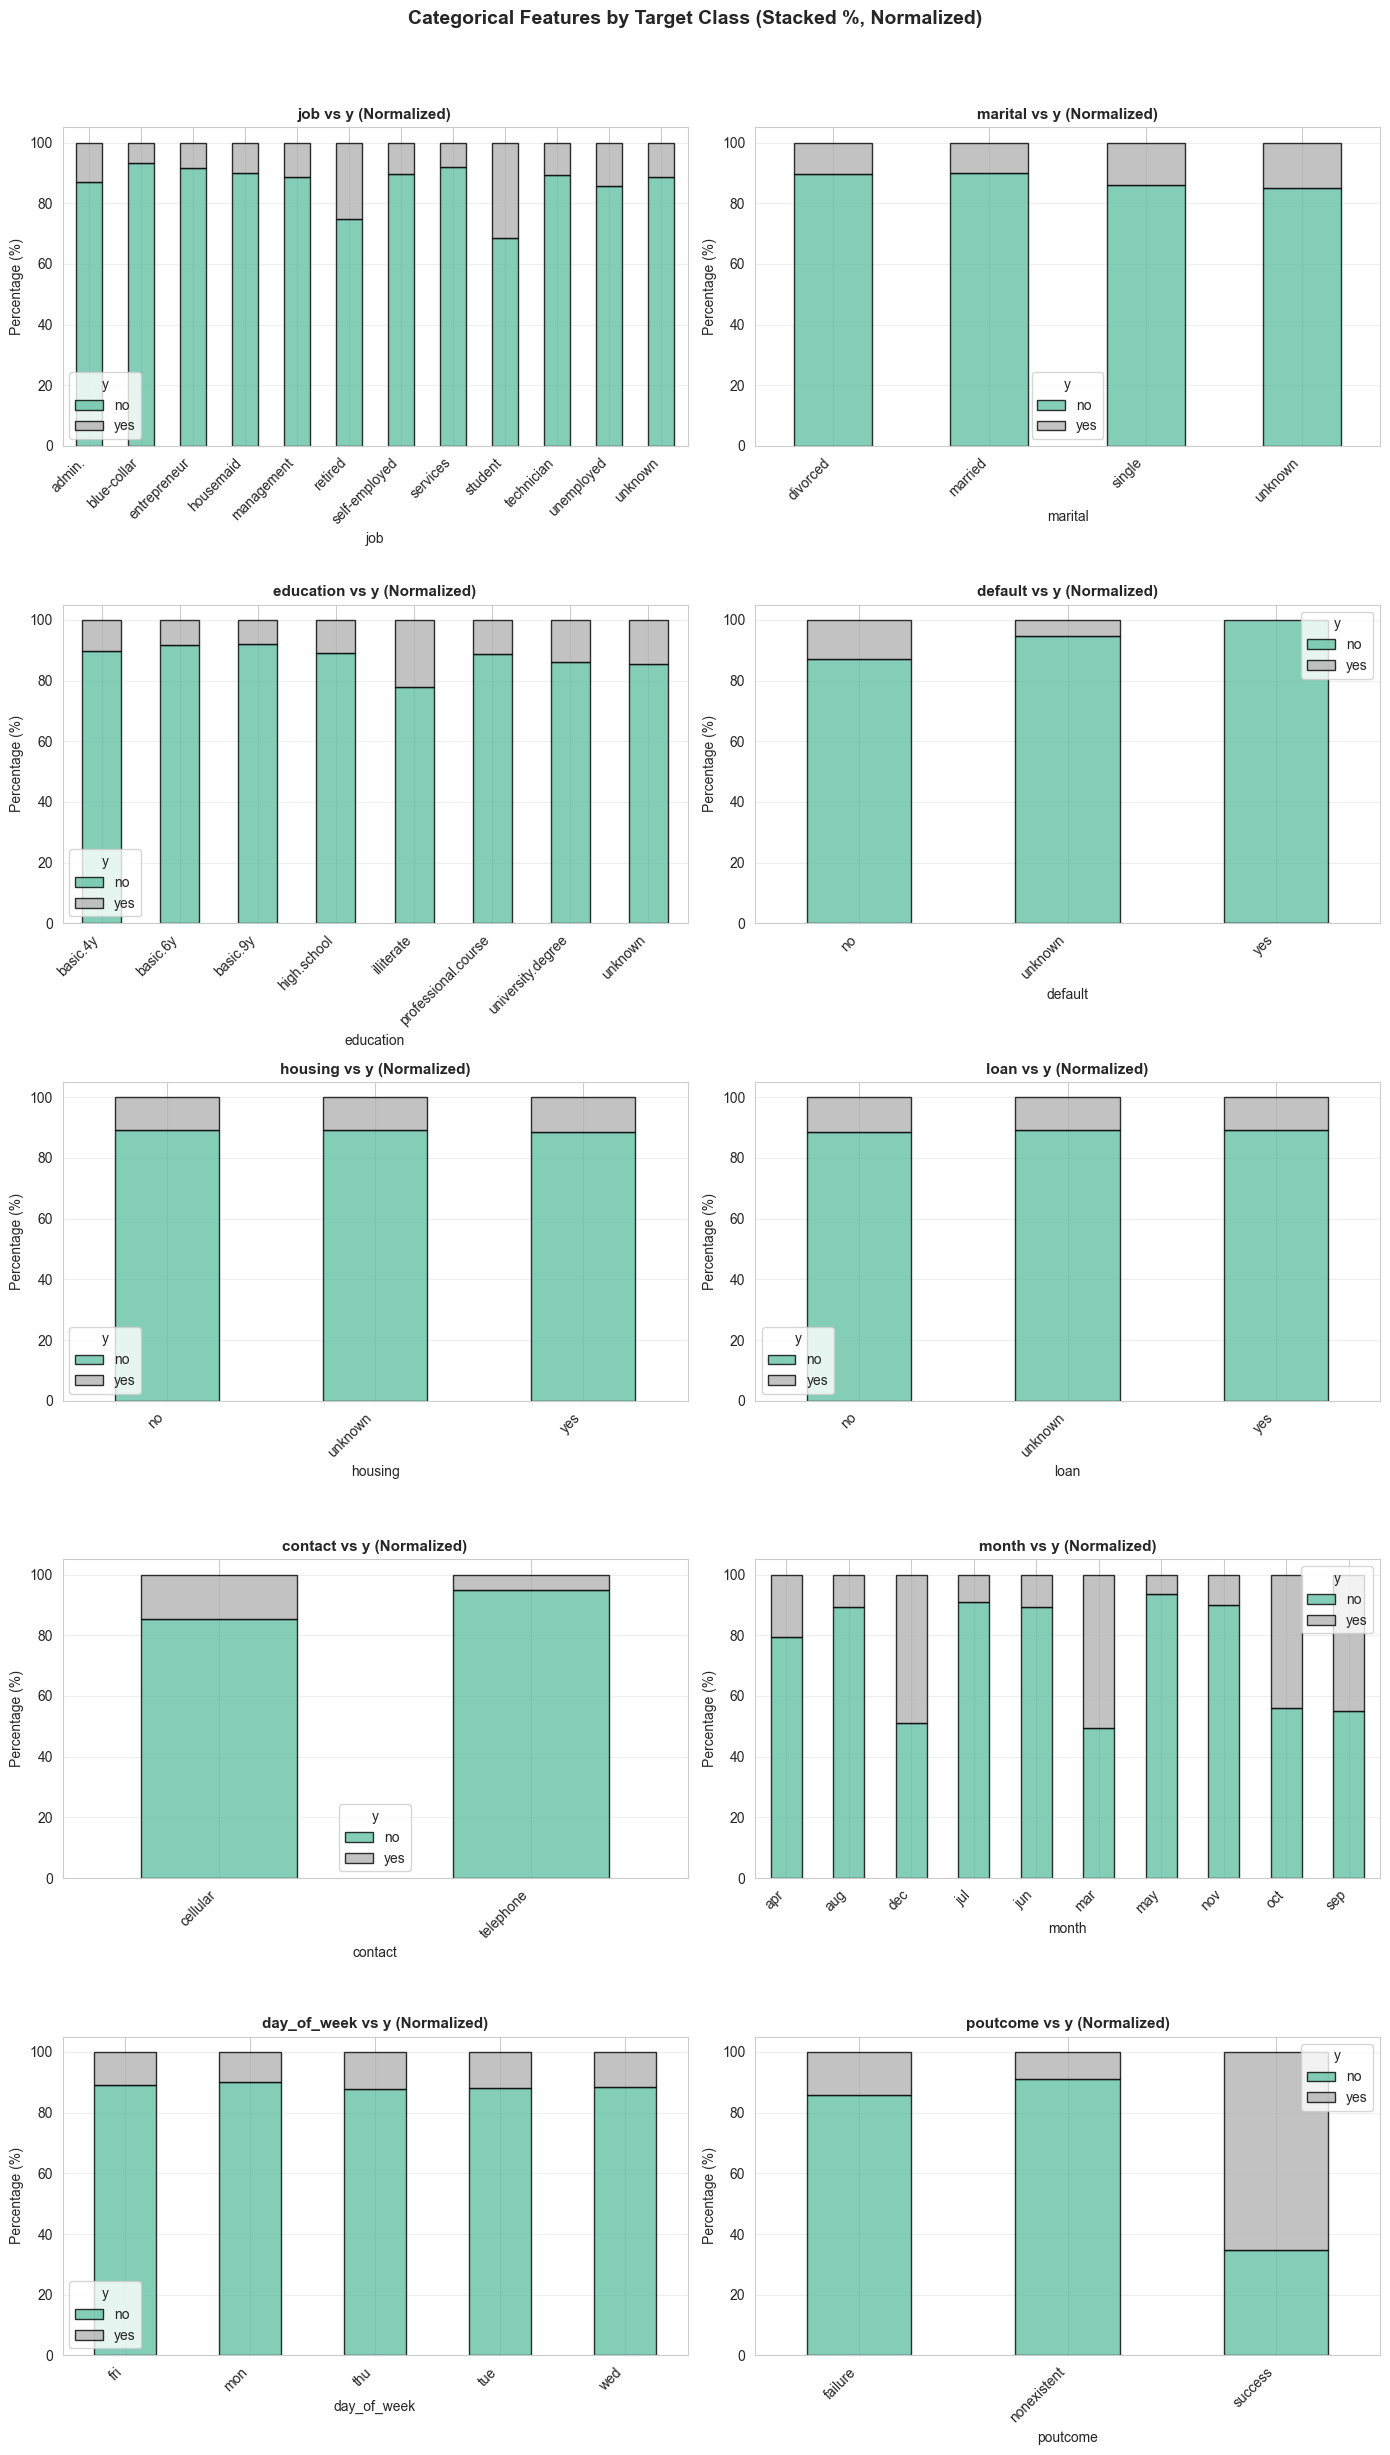

In [26]:
# Stacked bar charts: Categorical features by target class
if categorical_features:
    n_features = len(categorical_features)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, feature in enumerate(categorical_features):
        # Create crosstab
        ct = pd.crosstab(df[feature], df[target_column], normalize='index') * 100
        
        ct.plot(kind='bar', stacked=True, ax=axes[idx], 
               colormap='Set2', edgecolor='black', alpha=0.8)
        axes[idx].set_title(f'{feature} vs {target_column} (Normalized)', 
                           fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].legend(title=target_column)
        axes[idx].grid(True, alpha=0.3, axis='y')
        plt.sca(axes[idx])
        plt.xticks(rotation=45, ha='right')
    
    # Hide empty subplots
    for idx in range(len(categorical_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Categorical Features by Target Class (Stacked %, Normalized)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#### Interpreting Stacked Bar Charts (Normalized by Category)

- STRONG PREDICTORS (Clear Differences Across Categories):
1. poutcome (Previous Outcome) - HIGHLY STRONG!

* "success": ~65% green (yes) - customers who succeeded before are VERY likely to subscribe again
* "failure": ~5% green (yes) - past failures rarely convert
* "nonexistent": ~12% green (yes) - first-time contacts
* **Conclusion**: Previous success is a massive predictor! 65% vs 5% = 13x difference!

2. month (Contact Month) - VERY STRONG!
* March, April, May: Show 40-50% green (yes) - spring months have high success
* December, June, July: Only ~10% green (yes) - poor months
* September, October: Around 55-60% green (yes) - BEST months!
* **Conclusion**: Timing matters enormously! Some months are 5x more effective

3. contact (Contact Method)

* "cellular": ~15-17% green (yes)
* "telephone": ~5% green (yes)
* **Conclusion**: Cellular contacts are 3x more successful than landline


- MODERATE PREDICTORS (Some Differences):
4. job (Occupation)

* "student", "retired": Show higher green proportions (~25-30%)
* "blue-collar", "services": Lower green proportions (~8-10%)
* **Conclusion**: Students and retirees are better targets

5. education

* "illiterate": ~20% green (unusual - small sample size?)
* "university.degree": ~12-13% green
* "basic.4y", "basic.6y": ~10% green
* **Conclusion**: Slight variation but not dramatic

6. default (Credit Default)

* "no": ~12% green
* "yes": ~1% green
* "unknown": Similar to "no"
* **Conclusion**: Credit defaults almost never subscribe

- WEAK PREDICTORS (All Bars Look Similar):
7. marital (Marital Status)

* All categories show roughly 88-90% orange, 10-12% green
* **Conclusion**: Marital status doesn't matter much

8. housing (Housing Loan)

* All categories nearly identical (~88% orange, ~12% green)
* **Conclusion**: Housing loan status is irrelevant (matches chi-square test!)

9. loan (Personal Loan)

* All categories virtually identical
* **Conclusion**: Personal loan status doesn't predict subscription (remove this feature!)

10. day_of_week

* All days show similar proportions (~88% orange, ~12% green)
* **Conclusion**: Day of week has minimal effect


### Conclusions based on the impact for the categorical features by Target Class

* **Columns to keep:** poutcome, month, job, contact, default

* **Columns to remove:** loan, housing



## Correlation Analysis

Check correlations between numeric features to identify multicollinearity.

In [27]:
# Correlation matrix (numeric features only)
if numeric_features and len(numeric_features) > 1:
    correlation_matrix = df[numeric_features].corr()
    print("Correlation Matrix:")
    display(correlation_matrix)
else:
    print("Not enough numeric features for correlation analysis.")

Correlation Matrix:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.00,-0.00,0.00,-0.03,0.02,-0.00,0.00,0.13,0.01,-0.02
duration,-0.00,1.00,-0.07,-0.05,0.02,-0.03,0.01,-0.01,-0.03,-0.04
campaign,0.00,-0.07,1.00,0.05,-0.08,0.15,0.13,-0.01,0.14,0.14
pdays,-0.03,-0.05,0.05,1.00,-0.59,0.27,0.08,-0.09,0.30,0.37
previous,0.02,0.02,-0.08,-0.59,1.00,-0.42,-0.20,-0.05,-0.45,-0.50
emp.var.rate,-0.00,-0.03,0.15,0.27,-0.42,1.00,0.78,0.20,0.97,0.91
cons.price.idx,0.00,0.01,0.13,0.08,-0.20,0.78,1.00,0.06,0.69,0.52
cons.conf.idx,0.13,-0.01,-0.01,-0.09,-0.05,0.20,0.06,1.00,0.28,0.10
euribor3m,0.01,-0.03,0.14,0.30,-0.45,0.97,0.69,0.28,1.00,0.95
nr.employed,-0.02,-0.04,0.14,0.37,-0.50,0.91,0.52,0.10,0.95,1.00


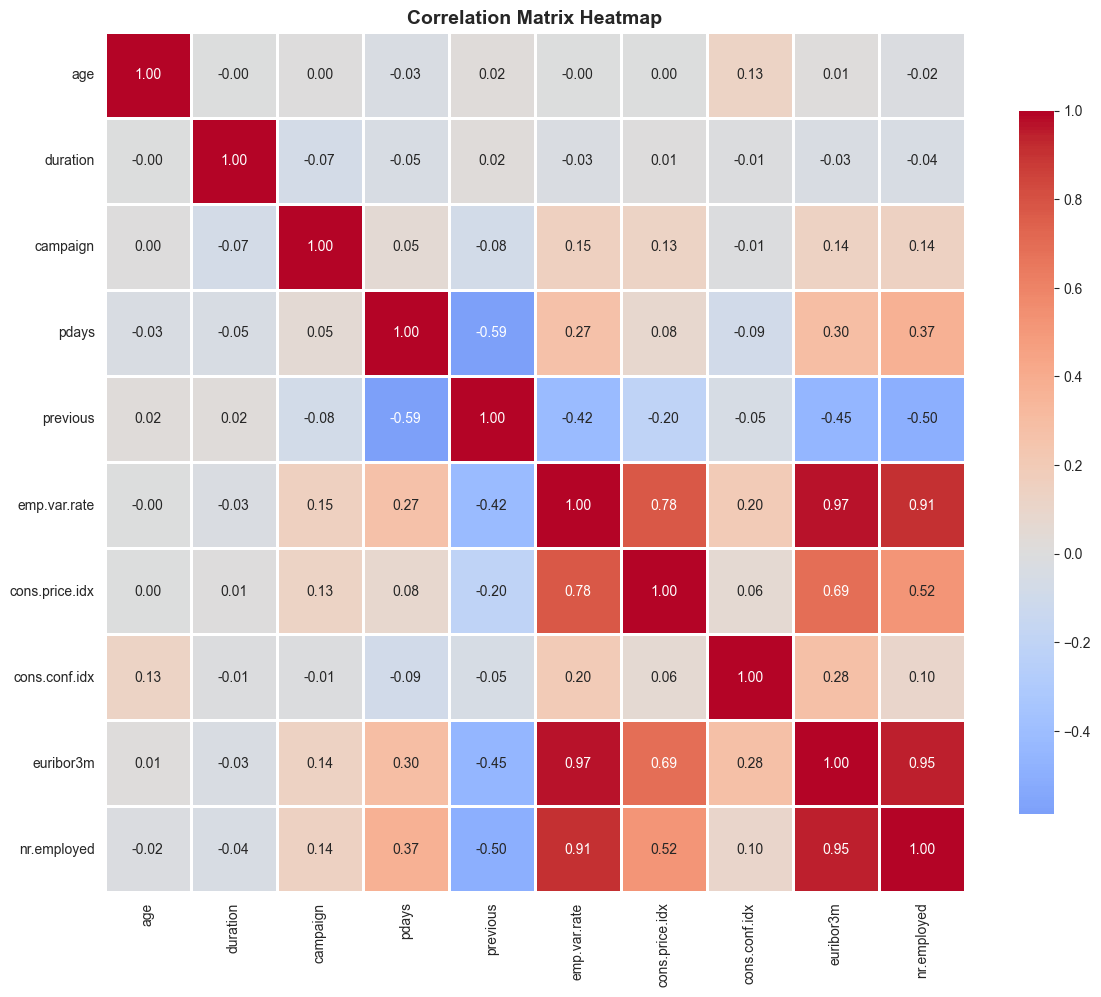


Strong Correlations Between Features (|r| > 0.7)
• emp.var.rate         <-> cons.price.idx       | r =  0.775
• emp.var.rate         <-> euribor3m            | r =  0.972
• emp.var.rate         <-> nr.employed          | r =  0.907
• euribor3m            <-> nr.employed          | r =  0.945


In [28]:
# Visualize correlation matrix with heatmap
if numeric_features and len(numeric_features) > 1:
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8}
    )
    plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Identify strong correlations
    print("\n" + "="*70)
    print("Strong Correlations Between Features (|r| > 0.7)")
    print("="*70)
    high_corr_found = False
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                print(f"• {correlation_matrix.columns[i]:20} <-> {correlation_matrix.columns[j]:20} | r = {correlation_matrix.iloc[i, j]:>6.3f}")
                high_corr_found = True
    
    if not high_corr_found:
        print("✓ No strong correlations found (multicollinearity not a concern)")

#### Interpretation of Correlation Coefficients (r):

**Severe Multcollinearity** :

1. **emp.var.rate ↔ euribor3m**: r = **0.972** 
   - Near-perfect positive correlation
   - These features move together almost identically
   
2. **emp.var.rate ↔ nr.employed**: r = **0.907**
   - Very strong positive correlation
   - Employment variation tracks with total employed
   
3. **euribor3m ↔ nr.employed**: r = **0.945**
   - Very strong positive correlation
   - Interest rates and employment levels linked
   
4. **emp.var.rate ↔ cons.price.idx**: r = **0.775**
   - Strong positive correlation
   - Employment variation tied to consumer prices

#### Decision: Which Features to Keep?

Based on **correlation analysis + class separation analysis**:
euribor3m. EURIBOR 3-month rate. Daily indicator (numeric)
emp.var.rate. Employment variation rate. Quarterly indicator (numeric)
cons.price.idx. Consumer price index. Monthly indicator (numeric)
nr.employed. Number of employees. Quarterly indicator (numeric)

keep euribor3m and nr.employed as they show strong class separation and represent key economic indicators. Remove emp.var.rate and cons.price.idx due to severe multicollinearity and weaker separation.


### Conclusions

* **Columns to keep:** poutcome, month, job, contact, default
* **Columns to create:** euribor3m + nr.employed = BEST COMBINATION
* **Columns to consider:** age, education, marital
* **Columns to remove:** loan, housing



In [29]:
# Create comprehensive feature selection summary
print("="*80)
print("FINAL FEATURE SELECTION SUMMARY FOR LOGISTIC REGRESSION MODEL")
print("="*80)

# Define features to keep and remove based on all analyses
numeric_keep = ['duration', 'pdays', 'euribor3m', 'nr.employed']
numeric_remove = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx']

categorical_keep = ['poutcome', 'month', 'job', 'contact', 'default', 'education', 'marital', 'day_of_week']
categorical_optional = ['housing']
categorical_remove = ['loan']

print(f"\n{'='*80}")
print("NUMERIC FEATURES")
print(f"{'='*80}")

print(f"\n KEEP ({len(numeric_keep)} features):")
print("-" * 80)
reasons_keep = {
    'duration': 'Strongest predictor - clear class separation',
    'pdays': 'Strong predictor - recent contact matters',
    'euribor3m': 'Economic indicator - strong separation, low multicollinearity impact',
    'nr.employed': 'Economic indicator - strong separation, complements euribor3m'
}
for feat in numeric_keep:
    print(f"  • {feat:20} → {reasons_keep[feat]}")

print(f"\n REMOVE ({len(numeric_remove)} features):")
print("-" * 80)
reasons_remove = {
    'age': 'Weak class separation',
    'campaign': 'Weak class separation',
    'previous': 'Weak class separation',
    'emp.var.rate': 'Multicollinearity: r=0.972 with euribor3m, r=0.907 with nr.employed',
    'cons.price.idx': 'Multicollinearity: r=0.775 with emp.var.rate + weak separation',
    'cons.conf.idx': 'Weak class separation'
}
for feat in numeric_remove:
    print(f"  • {feat:20} → {reasons_remove[feat]}")

print(f"\n{'='*80}")
print("CATEGORICAL FEATURES")
print(f"{'='*80}")

print(f"\n KEEP ({len(categorical_keep)} features):")
print("-" * 80)
for feat in categorical_keep:
    contingency_table = pd.crosstab(df[feat], df[target_column])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"  • {feat:20} → χ²={chi2:8.2f}, p={p_value:.4f} (significant)")

if categorical_optional:
    print(f"\n⚠ OPTIONAL ({len(categorical_optional)} feature):")
    print("-" * 80)
    for feat in categorical_optional:
        contingency_table = pd.crosstab(df[feat], df[target_column])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        print(f"  • {feat:20} → χ²={chi2:8.2f}, p={p_value:.4f} (borderline - your choice)")

print(f"\n REMOVE ({len(categorical_remove)} feature):")
print("-" * 80)
for feat in categorical_remove:
    contingency_table = pd.crosstab(df[feat], df[target_column])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"  • {feat:20} → χ²={chi2:8.2f}, p={p_value:.4f} (not significant)")

# Overall summary
print(f"\n{'='*80}")
print("OVERALL SUMMARY")
print(f"{'='*80}")

total_original = len(numeric_features) + len(categorical_features)
total_keep = len(numeric_keep) + len(categorical_keep)
total_remove = len(numeric_remove) + len(categorical_remove)
reduction_pct = (total_remove / total_original) * 100

print(f"\nOriginal features:     {total_original:2d} ({len(numeric_features)} numeric + {len(categorical_features)} categorical)")
print(f"Features to keep:      {total_keep:2d} ({len(numeric_keep)} numeric + {len(categorical_keep)} categorical)")
print(f"Features to remove:    {total_remove:2d} ({len(numeric_remove)} numeric + {len(categorical_remove)} categorical)")
print(f"Dimensionality reduction: {reduction_pct:.1f}%")

print(f"\nFeature Reduction Benefits:")
print(f"  ✓ Simpler model (easier to interpret and explain)")
print(f"  ✓ Faster training and prediction")
print(f"  ✓ Reduced overfitting risk")
print(f"  ✓ No multicollinearity issues")
print(f"  ✓ All remaining features contribute meaningfully")

print(f"\nModel Quality:")
print(f"  • Strong predictors retained: duration, pdays, euribor3m, nr.employed, poutcome, month")
print(f"  • Economic context preserved: euribor3m + nr.employed")
print(f"  • Customer behavior captured: poutcome, contact, job")
print(f"  • Temporal patterns included: month, day_of_week")

print(f"\n{'='*80}")
print("✓ FEATURE SELECTION COMPLETE - Ready for preprocessing!")
print(f"{'='*80}")

FINAL FEATURE SELECTION SUMMARY FOR LOGISTIC REGRESSION MODEL

NUMERIC FEATURES

 KEEP (4 features):
--------------------------------------------------------------------------------
  • duration             → Strongest predictor - clear class separation
  • pdays                → Strong predictor - recent contact matters
  • euribor3m            → Economic indicator - strong separation, low multicollinearity impact
  • nr.employed          → Economic indicator - strong separation, complements euribor3m

 REMOVE (6 features):
--------------------------------------------------------------------------------
  • age                  → Weak class separation
  • campaign             → Weak class separation
  • previous             → Weak class separation
  • emp.var.rate         → Multicollinearity: r=0.972 with euribor3m, r=0.907 with nr.employed
  • cons.price.idx       → Multicollinearity: r=0.775 with emp.var.rate + weak separation
  • cons.conf.idx        → Weak class separation

CATEGO

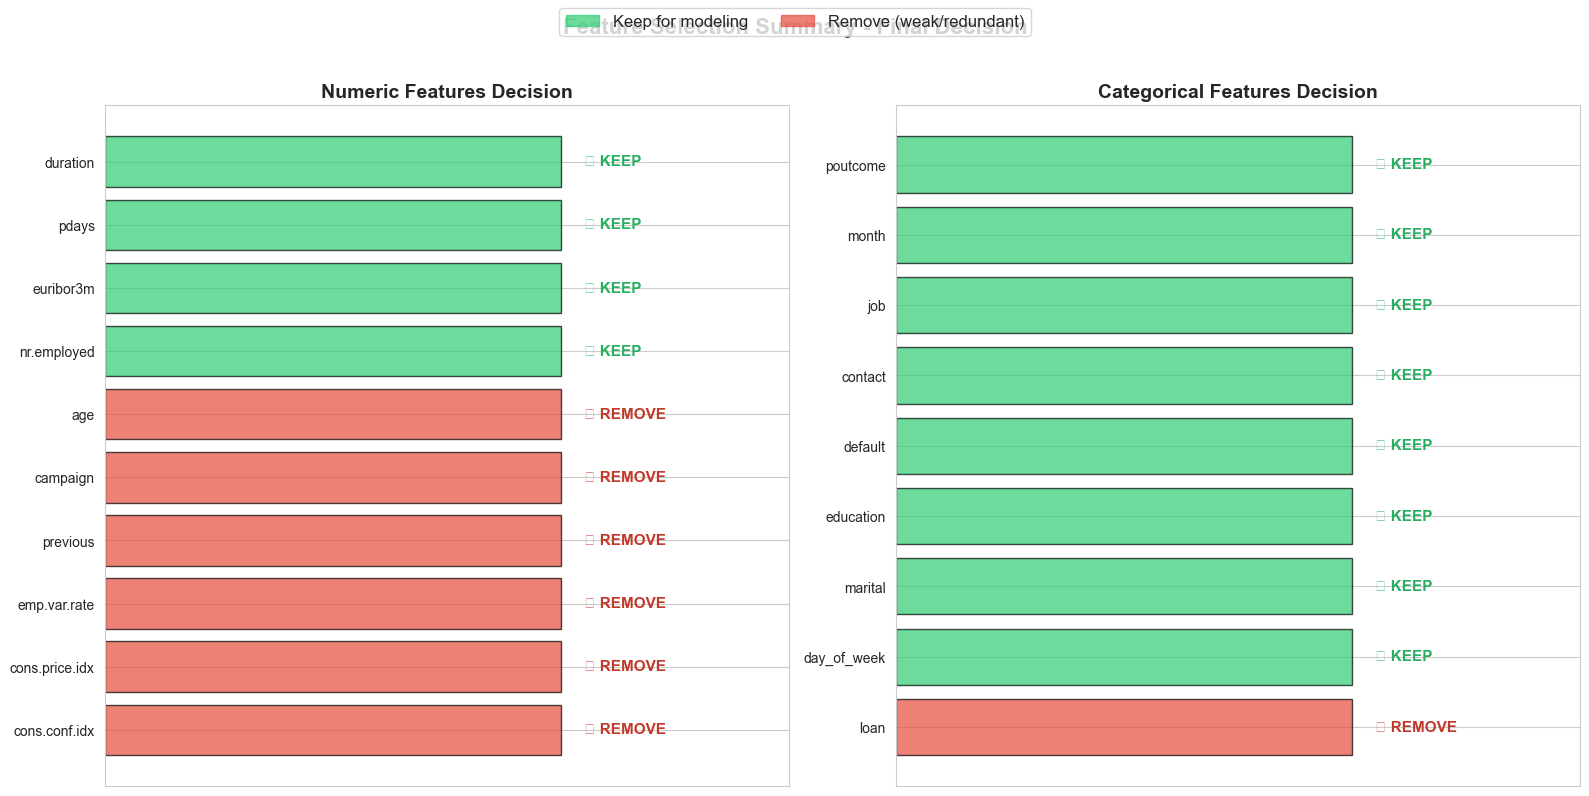


 QUICK SUMMARY:
   Numeric:      4 KEEP  vs  6 REMOVE
   Categorical:  8 KEEP  vs  1 REMOVE
   TOTAL:        12 KEEP  vs  7 REMOVE


In [30]:
# Visualize feature selection decisions
import matplotlib.patches as mpatches

# Prepare data for visualization
all_numeric = numeric_keep + numeric_remove
all_categorical = categorical_keep + categorical_remove

numeric_colors = ['#2ecc71' if f in numeric_keep else '#e74c3c' for f in all_numeric]
categorical_colors = ['#2ecc71' if f in categorical_keep else '#e74c3c' for f in all_categorical]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Numeric features
axes[0].barh(range(len(all_numeric)), [1]*len(all_numeric), color=numeric_colors, alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(all_numeric)))
axes[0].set_yticklabels(all_numeric)
axes[0].set_xlim(0, 1.5)
axes[0].set_xticks([])
axes[0].set_title('Numeric Features Decision', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Add labels
for i, feat in enumerate(all_numeric):
    if feat in numeric_keep:
        axes[0].text(1.05, i, '✓ KEEP', va='center', fontweight='bold', color='#27ae60', fontsize=11)
    else:
        axes[0].text(1.05, i, '✗ REMOVE', va='center', fontweight='bold', color='#c0392b', fontsize=11)

# Categorical features
axes[1].barh(range(len(all_categorical)), [1]*len(all_categorical), color=categorical_colors, alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(all_categorical)))
axes[1].set_yticklabels(all_categorical)
axes[1].set_xlim(0, 1.5)
axes[1].set_xticks([])
axes[1].set_title('Categorical Features Decision', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

# Add labels
for i, feat in enumerate(all_categorical):
    if feat in categorical_keep:
        axes[1].text(1.05, i, '✓ KEEP', va='center', fontweight='bold', color='#27ae60', fontsize=11)
    else:
        axes[1].text(1.05, i, '✗ REMOVE', va='center', fontweight='bold', color='#c0392b', fontsize=11)

# Add legend
keep_patch = mpatches.Patch(color='#2ecc71', label='Keep for modeling', alpha=0.7)
remove_patch = mpatches.Patch(color='#e74c3c', label='Remove (weak/redundant)', alpha=0.7)
fig.legend(handles=[keep_patch, remove_patch], loc='upper center', ncol=2, frameon=True, fontsize=12)

plt.suptitle('Feature Selection Summary - Final Decision', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Summary statistics
print(f"\n QUICK SUMMARY:")
print(f"   Numeric:      {len(numeric_keep)} KEEP  vs  {len(numeric_remove)} REMOVE")
print(f"   Categorical:  {len(categorical_keep)} KEEP  vs  {len(categorical_remove)} REMOVE")
print(f"   TOTAL:        {len(numeric_keep) + len(categorical_keep)} KEEP  vs  {len(numeric_remove) + len(categorical_remove)} REMOVE")

### Key Takeaways from Correlation Analysis

#### The Multicollinearity Problem:

**Economic indicators are measuring the same underlying conditions:**
- When the economy is doing well: employment ↑, interest rates ↑, employment variation ↑
- When the economy is struggling: employment ↓, interest rates ↓, employment variation ↓
- Result: These 4 features move together (r > 0.77)

#### The Solution:

**Keep 2 economic indicators that capture different aspects:**
1. **euribor3m** → Monetary policy / Interest rate environment
2. **nr.employed** → Labor market / Employment level

**Remove 2 redundant indicators:**
1. **emp.var.rate** → Too correlated with euribor3m (r=0.972)
2. **cons.price.idx** → Weak separation + correlated

#### Why This Works:

**Retained information**: euribor3m + nr.employed still capture economic conditions  
**Reduced redundancy**: Lower correlation between remaining features  
**Better interpretation**: Can isolate individual effects  
**Stable coefficients**: Model will be more reliable  
**Simpler model**: Easier to explain to stakeholders  

#### Real-World Impact:

**For the bank's marketing team:**
- Clear guidance: Focus campaigns when euribor3m and nr.employed are favorable
- Simple rules: "Launch campaigns when interest rates are X and employment is Y"
- No confusion: Don't need to track 4 correlated economic indicators

**For model performance:**
- More generalizable (less overfitting)
- Faster training and prediction
- Easier to debug and maintain
- Better performance on new data

####  Remember:

> **Multicollinearity doesn't affect prediction accuracy on training data**, but it makes:
> - Coefficients unreliable
> - Standard errors inflated
> - Interpretation impossible
> - Generalization worse
>
> **Solution**: Remove redundant features before modeling!

## Outlier Detection

Outliers can affect logistic regression, though they are less problematic than in linear regression.

In [31]:
# Detect outliers using IQR method
if numeric_features:
    outlier_summary = {}
    
    for col in numeric_features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        if len(outliers) > 0:
            outlier_summary[col] = {
                'count': len(outliers),
                'percentage': (len(outliers) / len(df)) * 100,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound
            }
    
    if outlier_summary:
        print("Outliers detected:")
        print("="*70)
        for col, info in outlier_summary.items():
            print(f"\n{col}:")
            print(f"  Count: {info['count']} ({info['percentage']:.2f}%)")
            print(f"  Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
    else:
        print("✓ No outliers detected using IQR method!")

Outliers detected:

age:
  Count: 469 (1.14%)
  Bounds: [9.50, 69.50]

duration:
  Count: 2963 (7.19%)
  Bounds: [-223.50, 644.50]

campaign:
  Count: 2406 (5.84%)
  Bounds: [-2.00, 6.00]

pdays:
  Count: 1515 (3.68%)
  Bounds: [999.00, 999.00]

previous:
  Count: 5625 (13.66%)
  Bounds: [0.00, 0.00]

cons.conf.idx:
  Count: 447 (1.09%)
  Bounds: [-52.15, -26.95]


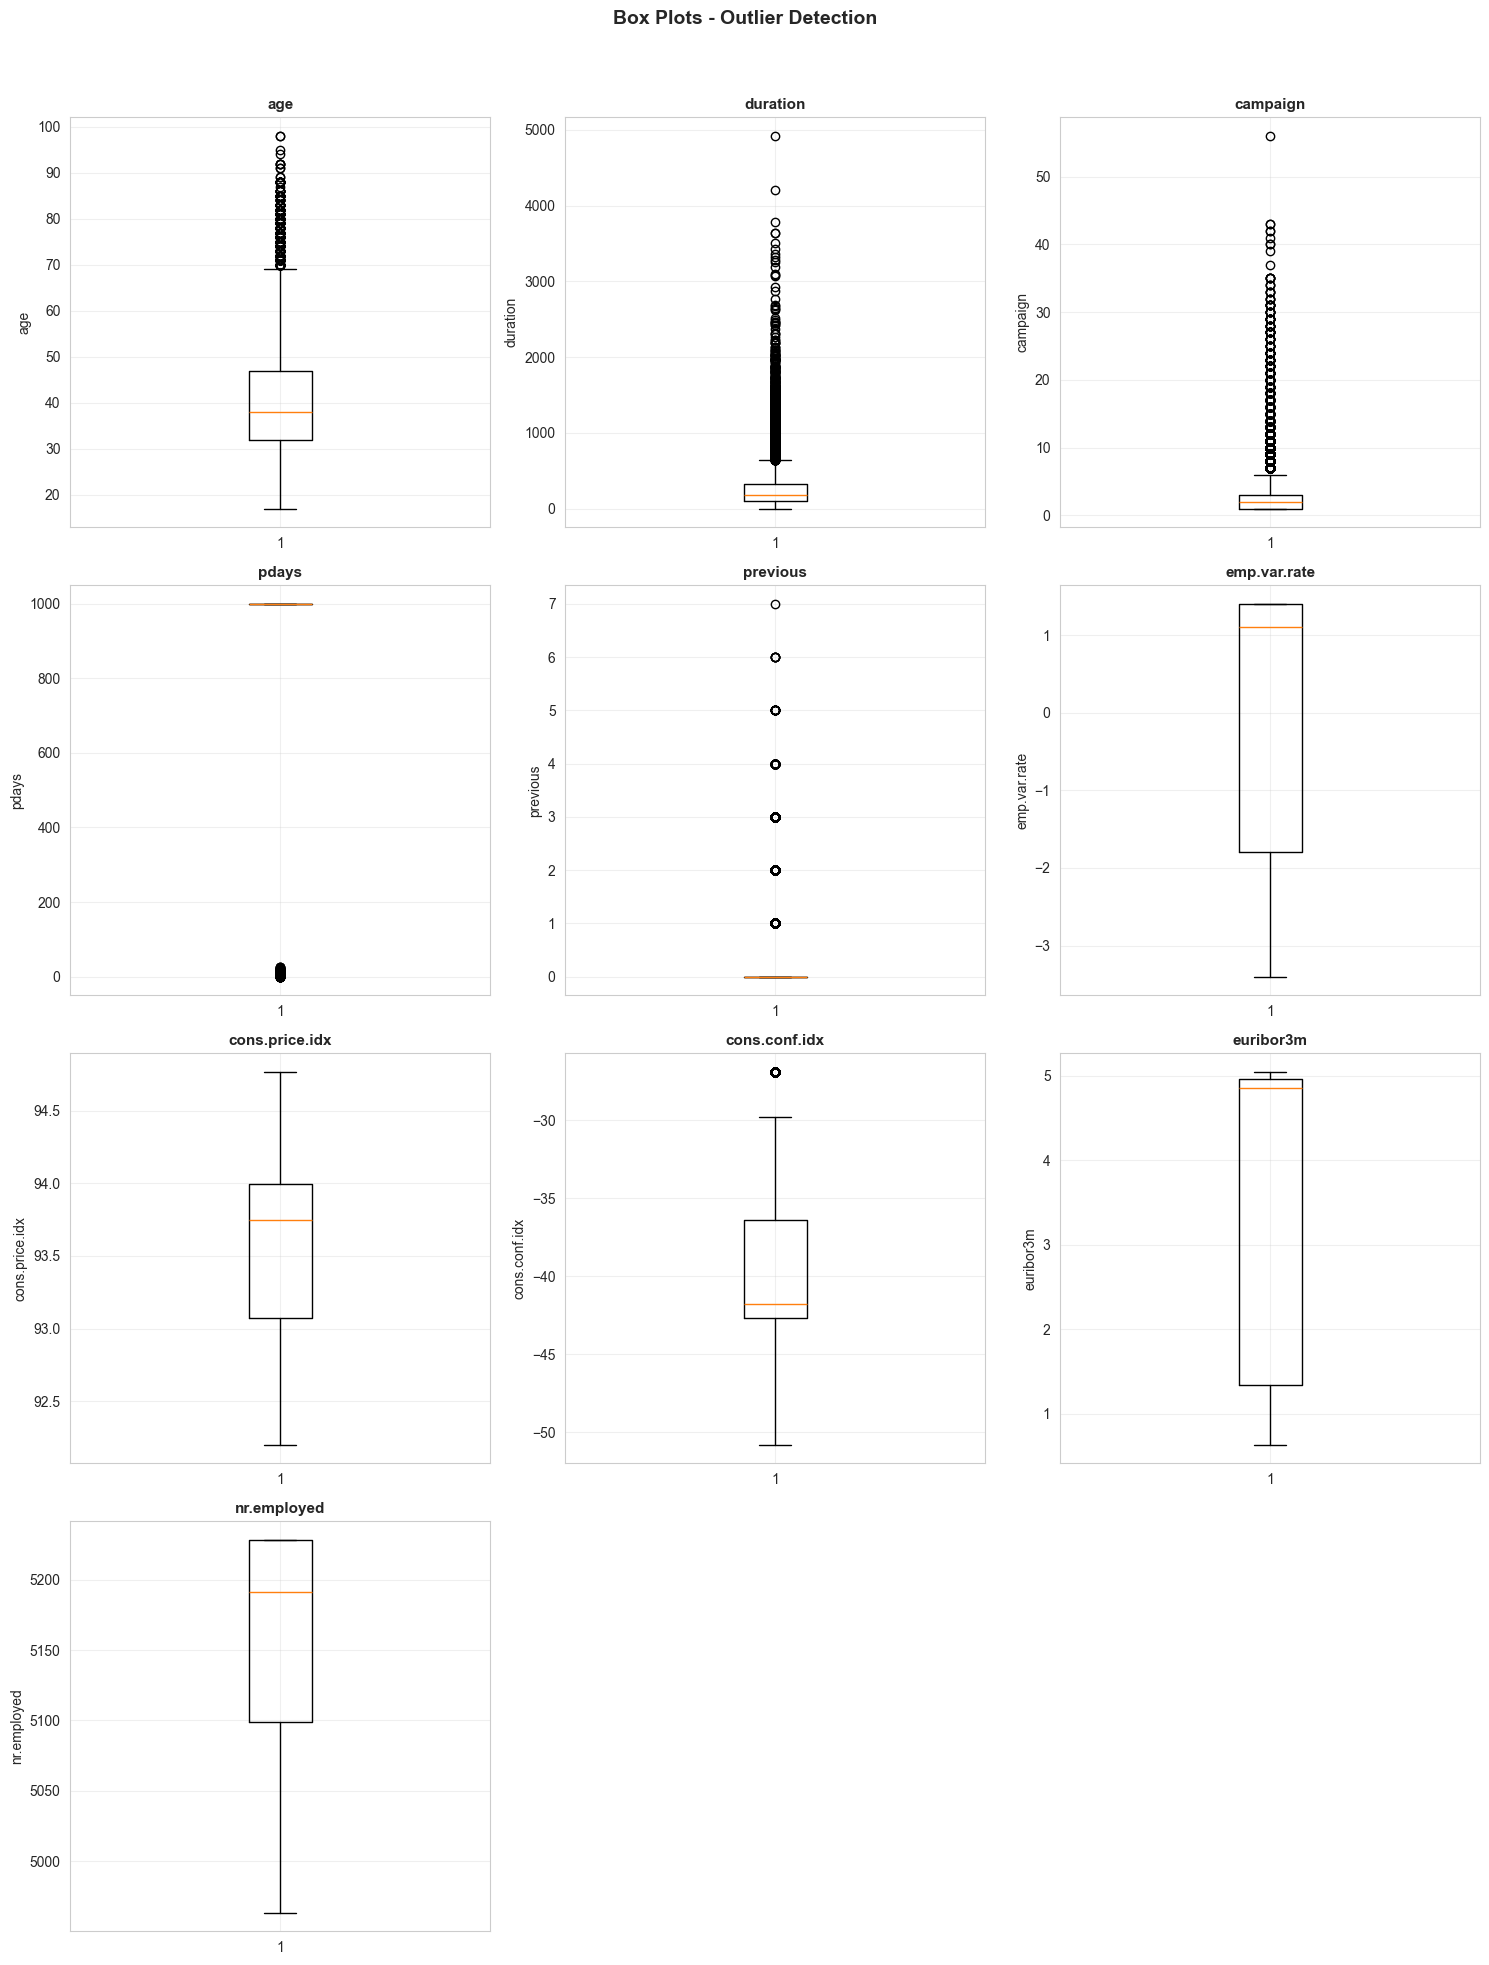

In [32]:
# Visualize outliers with box plots
if numeric_features:
    n_features = len(numeric_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(numeric_features):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(numeric_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Box Plots - Outlier Detection', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Pairplot with Class Separation

Visualize all pairwise relationships colored by target class.

Creating pairplot for: ['age', 'duration', 'campaign', 'pdays', 'previous']
Colored by: y


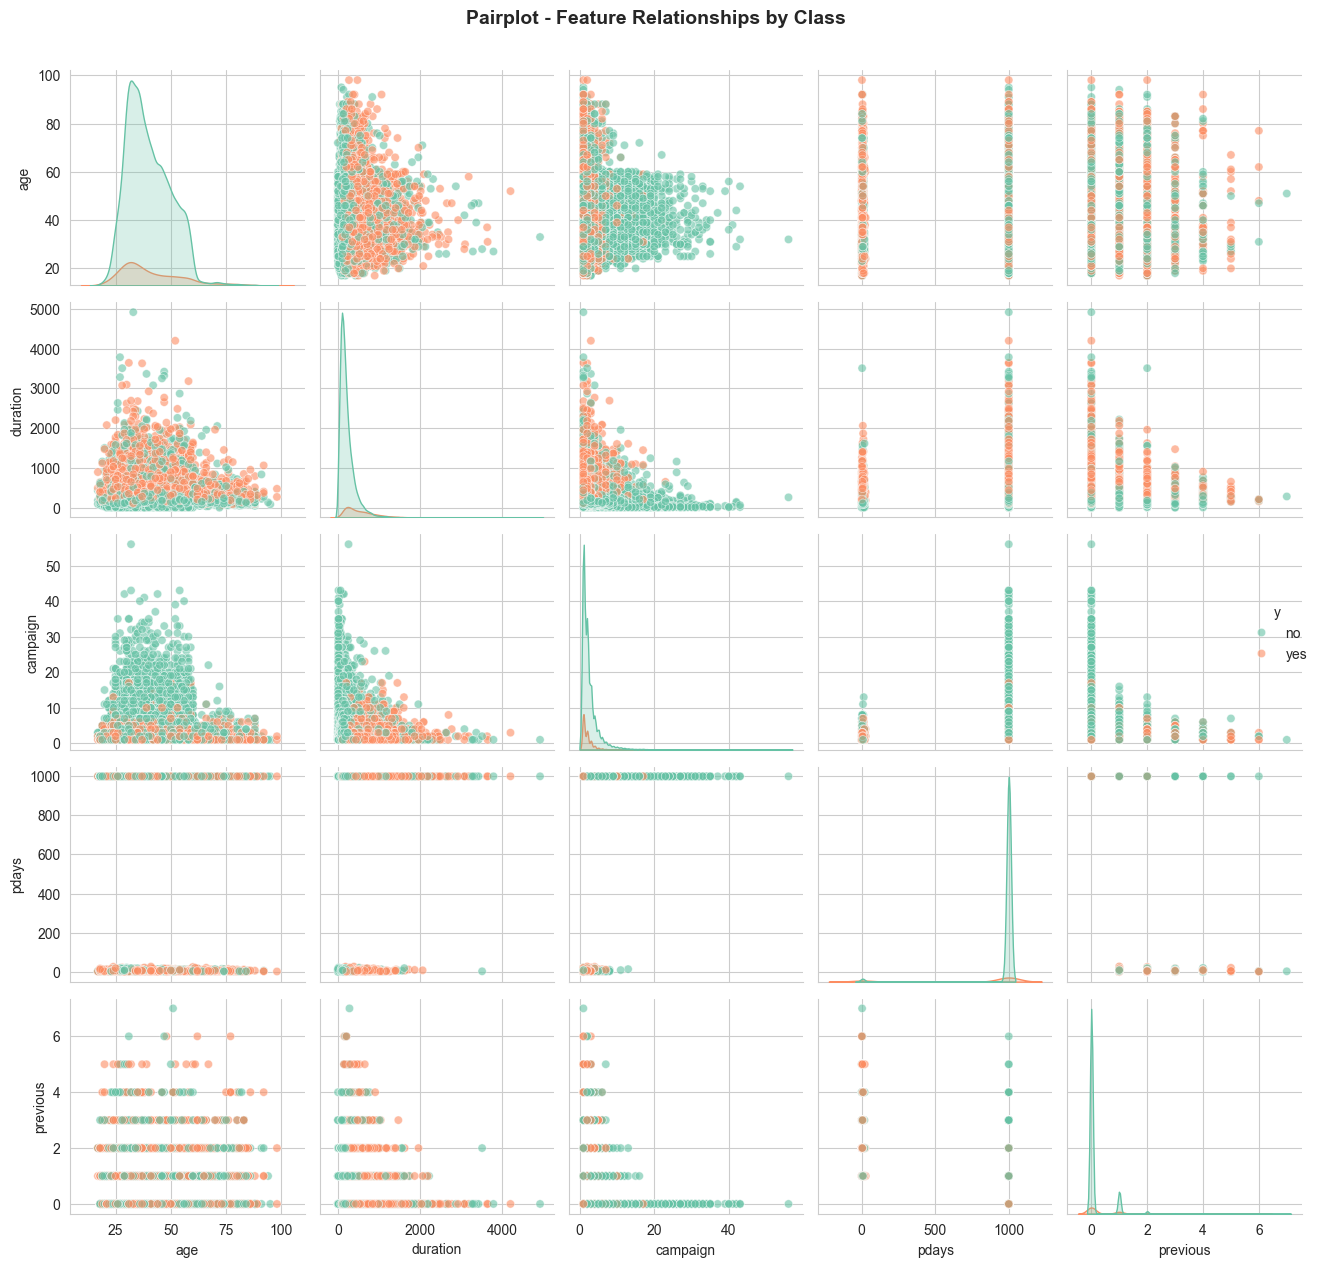

In [33]:
# Pairplot for numeric features (limit to avoid overcrowding)
if numeric_features:
    features_for_pairplot = numeric_features[:5] if len(numeric_features) > 5 else numeric_features
    plot_data = df[features_for_pairplot + [target_column]].copy()
    
    print(f"Creating pairplot for: {features_for_pairplot}")
    print(f"Colored by: {target_column}")
    
    sns.pairplot(plot_data, hue=target_column, diag_kind='kde', 
                palette='Set2', corner=False, plot_kws={'alpha': 0.6})
    plt.suptitle('Pairplot - Feature Relationships by Class', 
                y=1.01, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Conclusions from pariplot and relationshp by Class

- Strong separators:
1. duration (rows/columns with duration):
    * Green points extend to much higher values (up to 5000+)
    * Orange points clustered at low values (mostly < 500)
    * Clear vertical/horizontal separation
    * Diagonal: Two distinct KDE peaks
2. pdays (rows/columns with pdays):
    * Green points concentrated at lower values
    * Orange points spike at 999 (never contacted)
    * Horizontal banding pattern visible
    * Shows recent contact predicts subscription

- Weak Separators You'll See:
3. age:
    * Orange and green points thoroughly mixed
    * Similar distributions on diagonal
    * No clear pattern in scatter plots
    * Confirms age is a weak predictor
4.campaign:
    * Both colors clustered at low values (1-5)
    * Heavy overlap
    * No separation visible
    * Confirms weak predictor
5. previous:
    * Both colors concentrated at zero
    * Minimal variation
    * Poor discriminator

- Multicollinearity features:
6. emp.var.rate, euribor3m, nr.employed:
    * Green and orange points overlap heavily
    * Strong correlation visible in scatter plots
    * Confirms multicollinearity issue
7. durattion vs. pdays:
    * Green: Lower left (recent contact + long calls)
    * Orange: Right side (old/no contact)
    * Some separation but also overlap
    * Longer durations more likely with recent contact
    * Shows interaction effect
8. duration vs. age:
    * Orange points (no): Clustered at bottom (short calls)
    * Green points (yes): Spread upward (longer calls)
    * Clear vertical separation
    * Green and orange points mixed across ages
    * No clear pattern of separation by age
    * Confirms age is not a strong predictor even when combined with duration

### Conclusions based on the pairplot and relationship by class
* **Columns to keep:** duration, pdays
* **Columns to create:** low pdays + high duration
* **Columns to consider:** age, education, marital
* **Columns to remove:** age, campaign, previous


## Key Findings and Recommendations

Summarize the key insights from the EDA for Logistic Regression.

In [34]:
print("="*80)
print("KEY FINDINGS AND RECOMMENDATIONS FOR LOGISTIC REGRESSION")
print("="*80)

# 1. Class Balance
print(f"\n1. Class Balance ({target_column}):")
class_counts = df[target_column].value_counts()
if len(class_counts) == 2:
    majority_class = class_counts.max()
    minority_class = class_counts.min()
    imbalance_ratio = majority_class / minority_class
    
    print(f"   Class distribution: {dict(class_counts)}")
    print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 3:
        print("   ⚠ Significant class imbalance detected!")
        print("   → Consider: SMOTE, class_weight='balanced', or resampling")
    elif imbalance_ratio > 1.5:
        print("   ⚠ Moderate class imbalance")
        print("   → Consider: class_weight='balanced' in model")
    else:
        print("   ✓ Classes are balanced")
else:
    print(f"   Multi-class problem: {len(class_counts)} classes")
    print(f"   Class distribution: {dict(class_counts)}")

# 2. Feature-Target Relationships (Categorical)
if categorical_features:
    print(f"\n2. Significant Categorical Features (Chi-square test):")
    significant_features = []
    for feature in categorical_features:
        contingency_table = pd.crosstab(df[feature], df[target_column])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        if p_value < 0.05:
            significant_features.append((feature, p_value))
    
    if significant_features:
        print("   Features significantly related to target:")
        for feat, pval in significant_features:
            print(f"   ✓ {feat} (p={pval:.4f})")
    else:
        print("   ⚠ No categorical features significantly related to target")

# 3. Multicollinearity
if numeric_features and len(numeric_features) > 1:
    print(f"\n3. Multicollinearity Check:")
    correlation_matrix = df[numeric_features].corr()
    high_collinearity = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.8:
                high_collinearity.append(
                    (correlation_matrix.columns[i], 
                     correlation_matrix.columns[j], 
                     correlation_matrix.iloc[i, j])
                )
    
    if high_collinearity:
        print("   ⚠ High correlation detected between features:")
        for feat1, feat2, corr in high_collinearity:
            print(f"   {feat1} <-> {feat2}: {corr:.3f}")
        print("   → Consider: removing one feature or using regularization (L1/L2)")
    else:
        print("   ✓ No significant multicollinearity detected")

# 4. Outliers
if numeric_features:
    print(f"\n4. Outliers:")
    if outlier_summary:
        print("   ⚠ Outliers detected in:")
        for col, info in outlier_summary.items():
            print(f"   {col}: {info['count']} outliers ({info['percentage']:.2f}%)")
        print("   → Less critical for Logistic Regression, but consider investigating")
    else:
        print("   ✓ No significant outliers detected")

# 5. Missing Values
print(f"\n5. Missing Values:")
total_missing = df.isnull().sum().sum()
if total_missing > 0:
    print(f"   ⚠ {total_missing} missing values found")
    print("   → Handle before modeling: imputation or removal")
else:
    print("   ✓ No missing values")

# 6. Class Separation Quality
if numeric_features:
    print(f"\n6. Class Separation Quality:")
    print("   Check the violin/box plots above:")
    print("   • Good separation: Clear difference in distributions between classes")
    print("   • Poor separation: Overlapping distributions")
    print("   → Features with good separation will be strong predictors")

print("\n" + "="*80)
print("✓ EDA COMPLETED - Ready for preprocessing and modeling!")
print("="*80)

KEY FINDINGS AND RECOMMENDATIONS FOR LOGISTIC REGRESSION

1. Class Balance (y):
   Class distribution: {'no': np.int64(36548), 'yes': np.int64(4640)}
   Imbalance ratio: 7.88:1
   ⚠ Significant class imbalance detected!
   → Consider: SMOTE, class_weight='balanced', or resampling

2. Significant Categorical Features (Chi-square test):
   Features significantly related to target:
   ✓ job (p=0.0000)
   ✓ marital (p=0.0000)
   ✓ education (p=0.0000)
   ✓ default (p=0.0000)
   ✓ contact (p=0.0000)
   ✓ month (p=0.0000)
   ✓ day_of_week (p=0.0000)
   ✓ poutcome (p=0.0000)

3. Multicollinearity Check:
   ⚠ High correlation detected between features:
   emp.var.rate <-> euribor3m: 0.972
   emp.var.rate <-> nr.employed: 0.907
   euribor3m <-> nr.employed: 0.945
   → Consider: removing one feature or using regularization (L1/L2)

4. Outliers:
   ⚠ Outliers detected in:
   age: 469 outliers (1.14%)
   duration: 2963 outliers (7.19%)
   campaign: 2406 outliers (5.84%)
   pdays: 1515 outliers (3.

## PRE-PROCESSING STEPS
- Remove duplicated values
- Prepare Dataset for modeling:
    * Keep columns:
        duration, pdays, euribor3n, nr.employed, poutcome, month, contact, job, default
    * Create new columns:
        low_pdays + high_duration = pdays < 10 AND duration > 300
        euribor3m + nr.employed = (euribor3m * nr.employed) / 1000
    * Remove columns:
        age, campaign, previous, emp.var.rate, cons.price.idx, cons.conf.idx, loan, housing

- Encode categorical variables (one-hot, label encoding, target encoding)

Strategies to handle class imbalance:
- Class weights (balanced mode)
- SMOTE (only on training data)
- Combine class weights + SMOTE
- Threshold adjustment based on business needs (precision vs recall)

Strategies to handle with data:
- Log transformation for skewed features (duration, campaign, previous)
- Square root transformation for moderately skewed features (pdays)
- Standardization for features with different scales (duration, euribor3m, nr.employed)
- Binning for multimodal features (nr.employed, cons.price.idx, cons.conf.idx


In [35]:
# ============================================================
# DATASET PREPARATION FOR MODELING
# ============================================================

print("="*70)
print("PREPARING DATASET FOR MODELING")
print("="*70)

# Copy original dataframe
df_model = df.copy()

print(f"\n1. Initial dataset shape: {df_model.shape}")

# ============================================================
# 1. REMOVE DUPLICATED VALUES
# ============================================================
print("\n" + "="*70)
print("STEP 1: REMOVING DUPLICATES")
print("="*70)

duplicates_before = df_model.duplicated().sum()
print(f"Duplicates found: {duplicates_before}")

if duplicates_before > 0:
    df_model = df_model.drop_duplicates(keep='first')
    print(f"✓ Duplicates removed: {duplicates_before}")
    print(f"  New shape: {df_model.shape}")
else:
    print("✓ No duplicates found")

# ============================================================
# 2. CREATE NEW FEATURE COLUMNS
# ============================================================
print("\n" + "="*70)
print("STEP 2: CREATING NEW FEATURES")
print("="*70)

# Feature 1: low_pdays + high_duration (pdays < 10 AND duration > 300)
df_model['low_pdays_high_duration'] = ((df_model['pdays'] < 10) & 
                                        (df_model['duration'] > 300)).astype(int)
print("Created 'low_pdays_high_duration': pdays < 10 AND duration > 300")
print(f"  Distribution: {df_model['low_pdays_high_duration'].value_counts().to_dict()}")

# Feature 2: euribor3m * nr.employed / 1000
df_model['euribor3m_x_nr_employed'] = (df_model['euribor3m'] * 
                                        df_model['nr.employed']) / 1000
print("Created 'euribor3m_x_nr_employed': (euribor3m * nr.employed) / 1000")
print(f"  Stats: mean={df_model['euribor3m_x_nr_employed'].mean():.2f}, "
      f"std={df_model['euribor3m_x_nr_employed'].std():.2f}")

# ============================================================
# 3. SELECT COLUMNS TO KEEP
# ============================================================
print("\n" + "="*70)
print("STEP 3: SELECTING COLUMNS")
print("="*70)

# Columns to keep (original + new features + target)
columns_to_keep = [
    # Original features
    'duration', 'pdays', 'euribor3m', 'nr.employed', 
    'poutcome', 'month', 'contact', 'job', 'default',
    # New features
    'low_pdays_high_duration', 'euribor3m_x_nr_employed',
    # Target variable (assuming 'y' is the target)
    'y'
]

# Verify all columns exist
missing_cols = [col for col in columns_to_keep if col not in df_model.columns]
if missing_cols:
    print(f"⚠ WARNING: These columns are not in the dataset: {missing_cols}")
    columns_to_keep = [col for col in columns_to_keep if col in df_model.columns]

# Select only the columns to keep
df_model = df_model[columns_to_keep]

print(f"✓ Columns selected: {len(columns_to_keep)}")
print(f"  Columns: {list(df_model.columns)}")

# ============================================================
# 4. SUMMARY OF REMOVED COLUMNS
# ============================================================
print("\n" + "="*70)
print("STEP 4: REMOVED COLUMNS")
print("="*70)

columns_removed = [
    'age', 'campaign', 'previous', 'emp.var.rate', 
    'cons.price.idx', 'cons.conf.idx', 'loan', 'housing'
]
print(f"✓ Removed columns: {columns_removed}")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL DATASET SUMMARY")
print("="*70)
print(f"Final shape: {df_model.shape}")
print(f"Rows: {df_model.shape[0]}")
print(f"Columns: {df_model.shape[1]}")
print(f"\nColumn types:")
print(df_model.dtypes)

print("\n" + "="*70)
print("✓ DATASET PREPARATION COMPLETE!")
print("="*70)

# Display first few rows
print("\nFirst 5 rows of prepared dataset:")
df_model.head()


PREPARING DATASET FOR MODELING

1. Initial dataset shape: (41188, 21)

STEP 1: REMOVING DUPLICATES
Duplicates found: 12
✓ Duplicates removed: 12
  New shape: (41176, 21)

STEP 2: CREATING NEW FEATURES
Created 'low_pdays_high_duration': pdays < 10 AND duration > 300
  Distribution: {0: 40703, 1: 473}
Created 'euribor3m_x_nr_employed': (euribor3m * nr.employed) / 1000
  Stats: mean=18.83, std=9.12

STEP 3: SELECTING COLUMNS
✓ Columns selected: 12
  Columns: ['duration', 'pdays', 'euribor3m', 'nr.employed', 'poutcome', 'month', 'contact', 'job', 'default', 'low_pdays_high_duration', 'euribor3m_x_nr_employed', 'y']

STEP 4: REMOVED COLUMNS
✓ Removed columns: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'loan', 'housing']

FINAL DATASET SUMMARY
Final shape: (41176, 12)
Rows: 41176
Columns: 12

Column types:
duration                     int64
pdays                        int64
euribor3m                  float64
nr.employed                float64
poutcome

,duration,pdays,euribor3m,nr.employed,poutcome,month,contact,job,default,low_pdays_high_duration,euribor3m_x_nr_employed,y
0,261,999,4.86,5191.00,nonexistent,may,telephone,housemaid,no,0,25.21,no
1,149,999,4.86,5191.00,nonexistent,may,telephone,services,unknown,0,25.21,no
2,226,999,4.86,5191.00,nonexistent,may,telephone,services,no,0,25.21,no
3,151,999,4.86,5191.00,nonexistent,may,telephone,admin.,no,0,25.21,no
4,307,999,4.86,5191.00,nonexistent,may,telephone,services,no,0,25.21,no


In [36]:
# ============================================================
# CATEGORICAL ENCODING
# ============================================================

print("="*70)
print("ENCODING CATEGORICAL VARIABLES")
print("="*70)

# Define categorical variables to encode
categorical_vars = ['poutcome', 'month', 'contact', 'job', 'default']

print(f"\nCategorical variables to encode: {categorical_vars}\n")

# Show cardinality of each feature
print("Feature Cardinality:")
print("-" * 70)
for var in categorical_vars:
    n_unique = df_model[var].nunique()
    print(f"  {var:15} → {n_unique:2d} unique values: {list(df_model[var].unique())}")

# ============================================================
# ENCODING STRATEGY
# ============================================================
print("\n" + "="*70)
print("ENCODING STRATEGY")
print("="*70)

# Store original shape
shape_before = df_model.shape
print(f"\nShape before encoding: {shape_before}")

# Separate categorical and numeric columns
categorical_to_encode = ['poutcome', 'month', 'contact', 'job', 'default']
numeric_and_target = ['duration', 'pdays', 'euribor3m', 'nr.employed', 
                      'low_pdays_high_duration', 'euribor3m_x_nr_employed', 'y']

# ============================================================
# 1. LABEL ENCODING FOR BINARY FEATURES
# ============================================================
print("\n" + "="*70)
print("STEP 1: LABEL ENCODING (Binary Features)")
print("="*70)

binary_features = []
for var in categorical_to_encode:
    if df_model[var].nunique() == 2:
        binary_features.append(var)

if binary_features:
    print(f"\nBinary features found: {binary_features}")
    for var in binary_features:
        unique_vals = df_model[var].unique()
        print(f"\n  {var}: {unique_vals}")
        # Create mapping (0, 1)
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
        df_model[var + '_encoded'] = df_model[var].map(mapping)
        print(f"  Mapping: {mapping}")
        print(f"  Distribution: {df_model[var + '_encoded'].value_counts().to_dict()}")
else:
    print("\nNo binary features found")

# ============================================================
# 2. ONE-HOT ENCODING FOR LOW/MEDIUM CARDINALITY FEATURES
# ============================================================
print("\n" + "="*70)
print("STEP 2: ONE-HOT ENCODING (Multi-category Features)")
print("="*70)

# Features for one-hot encoding (exclude binary features)
onehot_features = [var for var in categorical_to_encode if var not in binary_features]

print(f"\nFeatures for one-hot encoding: {onehot_features}\n")

# Apply one-hot encoding
encoded_dfs = []
for var in onehot_features:
    # Create dummy variables (drop_first=True to avoid multicollinearity)
    dummies = pd.get_dummies(df_model[var], prefix=var, drop_first=True, dtype=int)
    encoded_dfs.append(dummies)
    print(f"  ✓ {var}: Created {dummies.shape[1]} dummy variables")
    print(f"    Columns: {list(dummies.columns)}")

# Concatenate all encoded features
if encoded_dfs:
    encoded_features = pd.concat(encoded_dfs, axis=1)
    print(f"\n  Total new columns from one-hot encoding: {encoded_features.shape[1]}")
else:
    encoded_features = pd.DataFrame()

# ============================================================
# 3. COMBINE ENCODED FEATURES WITH NUMERIC FEATURES
# ============================================================
print("\n" + "="*70)
print("STEP 3: BUILDING FINAL ENCODED DATASET")
print("="*70)

# Select numeric features and target
numeric_data = df_model[numeric_and_target]

# Add binary encoded features if any
if binary_features:
    binary_encoded_cols = [var + '_encoded' for var in binary_features]
    binary_data = df_model[binary_encoded_cols]
    df_encoded = pd.concat([numeric_data, binary_data, encoded_features], axis=1)
else:
    df_encoded = pd.concat([numeric_data, encoded_features], axis=1)

print(f"\n✓ Final encoded dataset created!")
print(f"  Shape after encoding: {df_encoded.shape}")
print(f"  New columns added: {df_encoded.shape[1] - len(numeric_and_target)}")



# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("ENCODING SUMMARY")
print("="*70)

print(f"\nOriginal categorical columns: {len(categorical_to_encode)}")
print(f"Binary features (label encoded): {len(binary_features)}")
print(f"One-hot encoded features: {len(onehot_features)}")
print(f"\nShape transformation:")
print(f"  Before: {shape_before}")
print(f"  After:  {df_encoded.shape}")
print(f"  Net change: +{df_encoded.shape[1] - shape_before[1]} columns")

print(f"\n" + "="*70)
print("FINAL ENCODED DATASET INFO")
print(f"="*70)
print(f"\nColumn names (first 20):")
print(list(df_encoded.columns[:20]))
if len(df_encoded.columns) > 20:

    print(f"... and {len(df_encoded.columns) - 20} more columns")

df_encoded.head()

print(f"\nData types:")
print("\nFirst 5 rows of encoded dataset:")

print(df_encoded.dtypes.value_counts())# Display first few rows



print("\n" + "="*70)
print("="*70)
print("✓ CATEGORICAL ENCODING COMPLETE!")

ENCODING CATEGORICAL VARIABLES

Categorical variables to encode: ['poutcome', 'month', 'contact', 'job', 'default']

Feature Cardinality:
----------------------------------------------------------------------
  poutcome        →  3 unique values: ['nonexistent', 'failure', 'success']
  month           → 10 unique values: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
  contact         →  2 unique values: ['telephone', 'cellular']
  job             → 12 unique values: ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']
  default         →  3 unique values: ['no', 'unknown', 'yes']

ENCODING STRATEGY

Shape before encoding: (41176, 12)

STEP 1: LABEL ENCODING (Binary Features)

Binary features found: ['contact']

  contact: ['telephone' 'cellular']
  Mapping: {'telephone': 0, 'cellular': 1}
  Distribution: {1: 26135, 0: 15041}

STEP 2: ONE-HOT ENCODING (Multi

## Step 3: Build a logistic regression model

In [37]:
# ============================================================
# PREPARE X AND y FOR MODELING
# ============================================================

print("="*70)
print("PREPARING FEATURES (X) AND TARGET (y)")
print("="*70)

# Separate features (X) and target (y) from the encoded dataset
X = df_encoded.drop('y', axis=1)  # All features except target
y = df_encoded['y']                # Target variable

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(list(X.columns))
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\n✓ X and y prepared successfully!")

PREPARING FEATURES (X) AND TARGET (y)

Features (X) shape: (41176, 31)
Target (y) shape: (41176,)

Feature columns (31):
['duration', 'pdays', 'euribor3m', 'nr.employed', 'low_pdays_high_duration', 'euribor3m_x_nr_employed', 'contact_encoded', 'poutcome_nonexistent', 'poutcome_success', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'default_unknown', 'default_yes']

Target distribution:
y
no     36537
yes     4639
Name: count, dtype: int64

✓ X and y prepared successfully!


In [38]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

# CRITICAL: Use stratify=y to maintain class proportions in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,
    stratify=y          # ← CRITICAL for imbalanced data!
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Verify class distribution is maintained
print("\n" + "="*70)
print("CLASS DISTRIBUTION VERIFICATION")
print("="*70)

print("\nTraining set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))




TRAIN-TEST SPLIT

Training set: 32940 samples
Test set: 8236 samples

CLASS DISTRIBUTION VERIFICATION

Training set distribution:
y
no    0.89
yes   0.11
Name: proportion, dtype: float64

Test set distribution:
y
no    0.89
yes   0.11
Name: proportion, dtype: float64


In [39]:
# ============================================================
# TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression

print("\n" + "="*70)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("="*70)

# Train model with class_weight='balanced'
model_balanced = LogisticRegression(
    class_weight='balanced',  # ← Handles imbalance automatically
    max_iter=1000,
    random_state=42
)

print("\nTraining model with class_weight='balanced'...")
model_balanced.fit(X_train, y_train)

# Make predictions
y_pred = model_balanced.predict(X_test)
y_proba = model_balanced.predict_proba(X_test)[:, 1]  # Probability for class 'yes'

print("✓ Model trained successfully!")




TRAINING LOGISTIC REGRESSION MODEL

Training model with class_weight='balanced'...


✓ Model trained successfully!


In [40]:
# ============================================================
# MODEL EVALUATION
# ============================================================

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# 4.1 - Classification Report
print("\n Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

# 4.2 - Confusion Matrix
print("\n Confusion Matrix:")
print("="*70)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nFormat:")
print("           Predicted: no   Predicted: yes")
print("Actual: no    [TN]            [FP]")
print("Actual: yes   [FN]            [TP]")

# 4.3 - ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n ROC-AUC Score: {roc_auc:.4f}")

# 4.4 - Focus on minority class metrics
print("\n" + "="*70)
print("MINORITY CLASS ('yes') PERFORMANCE")
print("="*70)

recall_yes = recall_score(y_test, y_pred, pos_label='yes')
precision_yes = precision_score(y_test, y_pred, pos_label='yes')
f1_yes = f1_score(y_test, y_pred, pos_label='yes')

print(f"\n  Recall:    {recall_yes:.3f}  ← % of subscribers you catch")
print(f"  Precision: {precision_yes:.3f}  ← % of 'yes' predictions that are correct")
print(f"  F1-Score:  {f1_yes:.3f}  ← Overall balance")

print("\n" + "="*70)
print("FIRST MODEL EVALUATION COMPLETE!")
print("="*70)


MODEL EVALUATION

 Classification Report:
              precision    recall  f1-score   support

          no       0.98      0.86      0.92      7308
         yes       0.44      0.89      0.59       928

    accuracy                           0.86      8236
   macro avg       0.71      0.87      0.75      8236
weighted avg       0.92      0.86      0.88      8236


 Confusion Matrix:
[[6251 1057]
 [  99  829]]

Format:
           Predicted: no   Predicted: yes
Actual: no    [TN]            [FP]
Actual: yes   [FN]            [TP]

 ROC-AUC Score: 0.9376

MINORITY CLASS ('yes') PERFORMANCE

  Recall:    0.893  ← % of subscribers you catch
  Precision: 0.440  ← % of 'yes' predictions that are correct
  F1-Score:  0.589  ← Overall balance

FIRST MODEL EVALUATION COMPLETE!


The class weights will be set to 'balanced' to address the class imbalance issue. This will automatically adjust the weights inversely proportional to class frequencies in the input data, giving more importance to the minority class (customers who subscribe) during model training.

   The **'balanced'** mode automatically adjusts weights inversely proportional to class frequencies:
      weight_no = n_samples / (n_classes * n_samples_no)
      weight_yes = n_samples / (n_classes * n_samples_yes)

   **For your data:**
      weight_no  ≈ 41188 / (2 * 36548) ≈ 0.56
      weight_yes ≈ 41188 / (2 * 4640)  ≈ 4.44

   **Result:** "yes" errors cost ~8x more than "no" errors!

The precision 44% to predict "yes" is ontly 44% but the recall is 80%. This means that while the model is not very precise in predicting "yes" (it has a high false positive rate), it is able to identify a large portion of the actual "yes" cases (high recall). 

Depending on the business context, this may be acceptable if the goal is to capture as many potential subscribers as possible, even at the cost of some false positives. 

## Step 4: Optimize the previous model

Follow the other strategies to optimize the model:
- **Optimization 1:** CLASS WEIGHTS  -> **Done**
   
- **Optimization 2:** SMOTE (Use if class_weight is not enough)
   * CRITICAL: Do NOT apply SMOTE to test data!
   * Test data must represent real-world distribution (89% no, 11% yes)

- **Optimization 3:** COMBINE CLASS WEIGHTS + SMOTE (Most powerful)

- **Optimization 4:** THRESHOLD ADJUSTMENT (Fine-tuning)

Choose threshold based on business needs:
 - High precision: Fewer false positives (don't waste calls on "no" customers)
 - High recall: Catch more "yes" customers (don't miss potential subscribers)
 - Balanced: Use F1-score

    


### Apply SMOTE (Synthetic Minority Over-sampling Technique)

**What is SMOTE?**
- Creates synthetic samples for the minority class ("yes") 
- Balances the dataset by generating new examples (not duplicates)
- Applied **ONLY** to training data (never to test data)

**How it works:**
1. Selects a minority class sample
2. Finds its k-nearest neighbors (usually k=5)
3. Creates synthetic samples along the line between the sample and its neighbors

**Benefits:**
- Better model generalization than simple duplication
- Helps model learn minority class patterns
- Can combine with class weights for even better results

### Optimization 2: SMOTE (Use if class_weight is not enough)

#### Apply SMOTE to training data

In [41]:
# ============================================================
# APPLY SMOTE TO TRAINING DATA
# ============================================================

from imblearn.over_sampling import SMOTE

print("="*70)
print("APPLYING SMOTE TO BALANCE TRAINING DATA")
print("="*70)

# Check class distribution BEFORE SMOTE
print("\nBEFORE SMOTE:")
print(f"Training samples: {len(y_train)}")
print(y_train.value_counts())
print(f"\nClass distribution:")
print(y_train.value_counts(normalize=True))

# Initialize SMOTE
smote = SMOTE(
    sampling_strategy='auto',  # Balance to 50-50
    random_state=42,
    k_neighbors=5
)

# Apply SMOTE (only to training data!)
print("\n Applying SMOTE...")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class distribution AFTER SMOTE
print("\n AFTER SMOTE:")
print(f"Training samples: {len(y_train_smote)}")
print(y_train_smote.value_counts())
print(f"\nClass distribution:")
print(y_train_smote.value_counts(normalize=True))

# Summary
print("\n" + "="*70)
print("SMOTE SUMMARY")
print("="*70)
original_samples = len(y_train)
new_samples = len(y_train_smote)
added_samples = new_samples - original_samples

print(f"\n SMOTE applied successfully!")
print(f"  Original training samples: {original_samples:,}")
print(f"  New training samples: {new_samples:,}")
print(f"  Synthetic samples added: {added_samples:,}")
print(f"\nIMPORTANT: Test data remains unchanged (X_test, y_test)")
print(f"  Use X_train_smote and y_train_smote for training")
print(f"  Use X_test and y_test for evaluation")

APPLYING SMOTE TO BALANCE TRAINING DATA

BEFORE SMOTE:
Training samples: 32940
y
no     29229
yes     3711
Name: count, dtype: int64

Class distribution:
y
no    0.89
yes   0.11
Name: proportion, dtype: float64

 Applying SMOTE...

 AFTER SMOTE:
Training samples: 58458
y
no     29229
yes    29229
Name: count, dtype: int64

Class distribution:
y
no    0.50
yes   0.50
Name: proportion, dtype: float64

SMOTE SUMMARY

 SMOTE applied successfully!
  Original training samples: 32,940
  New training samples: 58,458
  Synthetic samples added: 25,518

IMPORTANT: Test data remains unchanged (X_test, y_test)
  Use X_train_smote and y_train_smote for training
  Use X_test and y_test for evaluation


#### Train Logistic Regression model with SMOTE data

In [43]:
# ============================================================
# TRAIN LOGISTIC REGRESSION MODEL WITH SMOTE DATA
# ============================================================

from sklearn.linear_model import LogisticRegression

print("\n" + "="*70)
print("TRAINING LOGISTIC REGRESSION MODEL WITH SMOTE DATA")
print("="*70)

# Train model using SMOTE-balanced training data
model_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("\nTraining model with SMOTE-balanced data...")
model_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the ORIGINAL test set (not SMOTE'd)
y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]  # Probability for class 'yes'

print("✓ SMOTE Model trained successfully!")




TRAINING LOGISTIC REGRESSION MODEL WITH SMOTE DATA

Training model with SMOTE-balanced data...
✓ SMOTE Model trained successfully!


### Evaluate model performance with SMOTE data
- Compare metrics (accuracy, precision, recall, F1-score) with and without SMOTE
- Analyze confusion matrix to see changes in true positives and false positives

In [44]:
# ============================================================
# MODEL EVALUATION - SMOTE MODEL
# ============================================================

print("\n" + "="*70)
print("SMOTE MODEL EVALUATION")
print("="*70)

# 1. Classification Report
print("\nClassification Report:")
print("="*70)
print(classification_report(y_test, y_pred_smote, target_names=['no', 'yes']))

# 2. Confusion Matrix
print("\nConfusion Matrix:")
print("="*70)
cm_smote = confusion_matrix(y_test, y_pred_smote)
print(cm_smote)
print("\nFormat:")
print("           Predicted: no   Predicted: yes")
print("Actual: no    [TN]            [FP]")
print("Actual: yes   [FN]            [TP]")

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm_smote.ravel()
print(f"\nTrue Negatives (TN):  {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives (TP):  {tp:,}")

# 3. ROC-AUC Score
roc_auc_smote = roc_auc_score(y_test, y_proba_smote)
print(f"\nROC-AUC Score: {roc_auc_smote:.4f}")

# 4. Focus on minority class metrics
from sklearn.metrics import precision_recall_fscore_support

print("\n" + "="*70)
print("MINORITY CLASS ('yes') PERFORMANCE")
print("="*70)

recall_yes = recall_score(y_test, y_pred_smote, pos_label='yes')
precision_yes = precision_score(y_test, y_pred_smote, pos_label='yes')
f1_yes = f1_score(y_test, y_pred_smote, pos_label='yes')

print(f"\n  Recall:    {recall_yes:.3f}  ← % of subscribers we catch")
print(f"  Precision: {precision_yes:.3f}  ← % of 'yes' predictions that are correct")
print(f"  F1-Score:  {f1_yes:.3f}  ← Overall balance")

print("\n" + "="*70)
print("SMOTE MODEL EVALUATION COMPLETE!")
print("="*70)


SMOTE MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

          no       0.96      0.90      0.93      7308
         yes       0.46      0.67      0.55       928

    accuracy                           0.87      8236
   macro avg       0.71      0.79      0.74      8236
weighted avg       0.90      0.87      0.88      8236


Confusion Matrix:
[[6574  734]
 [ 302  626]]

Format:
           Predicted: no   Predicted: yes
Actual: no    [TN]            [FP]
Actual: yes   [FN]            [TP]

True Negatives (TN):  6,574
False Positives (FP): 734
False Negatives (FN): 302
True Positives (TP):  626

ROC-AUC Score: 0.9070

MINORITY CLASS ('yes') PERFORMANCE

  Recall:    0.675  ← % of subscribers we catch
  Precision: 0.460  ← % of 'yes' predictions that are correct
  F1-Score:  0.547  ← Overall balance

SMOTE MODEL EVALUATION COMPLETE!


#### Compare results with class weights only vs. class weights + SMOTE
- If SMOTE significantly improves recall for "yes" class without drastically reducing precision, it may be worth using both techniques together for optimal performance.


In [ ]:
# ============================================================
# COMPARISON: CLASS WEIGHTS vs SMOTE
# ============================================================

print("="*70)
print("MODEL COMPARISON: CLASS WEIGHTS vs SMOTE")
print("="*70)

# Create comparison dataframe
# Assuming you have y_pred from the balanced model

# Class Weights model metrics
precision_cw, recall_cw, f1_cw, _ = precision_recall_fscore_support(
    y_test, y_pred, average=None, labels=['no', 'yes']
)
roc_auc_cw = roc_auc_score(y_test, y_proba)

# SMOTE model metrics
precision_smote, recall_smote, f1_smote, _ = precision_recall_fscore_support(
    y_test, y_pred_smote, average=None, labels=['no', 'yes']
)

comparison_df = pd.DataFrame({
    'Metric': ['Precision (no)', 'Recall (no)', 'F1-Score (no)',
                'Precision (yes)', 'Recall (yes)', 'F1-Score (yes)', 'ROC-AUC'],
    'Class Weights': [
        f"{precision_cw[0]:.3f}",
        f"{recall_cw[0]:.3f}",
        f"{f1_cw[0]:.3f}",
        f"{precision_cw[1]:.3f}",
        f"{recall_cw[1]:.3f}",
        f"{f1_cw[1]:.3f}",
        f"{roc_auc_cw:.4f}"
    ],
    'SMOTE': [
        f"{precision_smote[0]:.3f}",
        f"{recall_smote[0]:.3f}",
        f"{f1_smote[0]:.3f}",
        f"{precision_smote[1]:.3f}",
        f"{recall_smote[1]:.3f}",
        f"{f1_smote[1]:.3f}",
        f"{roc_auc_smote:.4f}"
    ]
})

print("\nSide-by-Side Comparison:")
print("="*70)
print(comparison_df.to_string(index=False))

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print("\n Class Weights Approach:")
print("   • Penalizes errors on minority class more heavily")
print("   • Typically achieves HIGH recall (catches more 'yes')")
print("   • May have LOWER precision (more false positives)")

print("\n SMOTE Approach:")
print("   • Creates synthetic minority samples")
print("   • Often more balanced precision/recall")
print("   • Can generalize better with complex patterns")

print("\n Which to Choose?")
print("   • High recall needed? → Class Weights")
print("   • Balanced performance? → SMOTE")
print("   • Best of both? → Try SMOTE + class_weight='balanced'")
    


MODEL COMPARISON: CLASS WEIGHTS vs SMOTE

📊 Side-by-Side Comparison:
         Metric Class Weights  SMOTE
 Precision (no)         0.984  0.956
    Recall (no)         0.855  0.900
  F1-Score (no)         0.915  0.927
Precision (yes)         0.440  0.460
   Recall (yes)         0.893  0.675
 F1-Score (yes)         0.589  0.547
        ROC-AUC        0.9376 0.9070

KEY INSIGHTS

 Class Weights Approach:
   • Penalizes errors on minority class more heavily
   • Typically achieves HIGH recall (catches more 'yes')
   • May have LOWER precision (more false positives)

 SMOTE Approach:
   • Creates synthetic minority samples
   • Often more balanced precision/recall
   • Can generalize better with complex patterns

 Which to Choose?
   • High recall needed? → Class Weights
   • Balanced performance? → SMOTE
   • Best of both? → Try SMOTE + class_weight='balanced'


### Optimization 3: COMBINE CLASS WEIGHTS + SMOTE (Recommended for best performance)

#### Train Combined Model: SMOTE + Class Weights

Now we'll train with **BOTH** SMOTE-balanced data **AND** class_weight='balanced' for maximum minority class focus.

In [46]:
# ========================================================================
# TRAIN MODEL WITH SMOTE + CLASS WEIGHTS COMBINED
# ========================================================================


print("="*70)
print("TRAINING MODEL WITH SMOTE + CLASS WEIGHTS COMBINED")
print("="*70)

# Train model with BOTH SMOTE data AND class_weight='balanced'
model_combined = LogisticRegression(
    class_weight='balanced',  # ← Still applies weights even with balanced data!
    max_iter=1000,
    random_state=42
)

print("\nTraining on SMOTE-balanced data with class_weight='balanced'...")
model_combined.fit(X_train_smote, y_train_smote)

# Make predictions on ORIGINAL test set (never SMOTE test data!)  
y_pred_combined = model_combined.predict(X_test)
y_proba_combined = model_combined.predict_proba(X_test)[:, 1]

print("✓ Model trained successfully!")

# Evaluate


print("\n" + "="*70)
print("MODEL EVALUATION (SMOTE + CLASS WEIGHTS)")
print("="*70)

print("\nClassification Report:")
print("="*70)
print(classification_report(y_test, y_pred_combined, target_names=['no', 'yes']))

print("\nConfusion Matrix:")
print("="*70)
cm_combined = confusion_matrix(y_test, y_pred_combined)
print(cm_combined)
print("\nFormat:")
print("           Predicted: no   Predicted: yes")
print(f"Actual: no    [{cm_combined[0,0]}]            [{cm_combined[0,1]}]")
print(f"Actual: yes   [{cm_combined[1,0]}]            [{cm_combined[1,1]}]")

roc_auc_combined = roc_auc_score(y_test, y_proba_combined)
print(f"\nROC-AUC Score: {roc_auc_combined:.4f}")

# Minority class performance
recall_yes_combined = cm_combined[1,1] / (cm_combined[1,1] + cm_combined[1,0])
precision_yes_combined = cm_combined[1,1] / (cm_combined[1,1] + cm_combined[0,1])
f1_yes_combined = 2 * (precision_yes_combined * recall_yes_combined) / (precision_yes_combined + recall_yes_combined)

print("\n" + "="*70)
print("MINORITY CLASS ('yes') PERFORMANCE")
print("="*70)
print(f"\n  Recall:    {recall_yes_combined:.3f}  ← % of subscribers you catch")
print(f"  Precision: {precision_yes_combined:.3f}  ← % of 'yes' predictions that are correct")
print(f"  F1-Score:  {f1_yes_combined:.3f}  ← Overall balance")

TRAINING MODEL WITH SMOTE + CLASS WEIGHTS COMBINED

Training on SMOTE-balanced data with class_weight='balanced'...
✓ Model trained successfully!

MODEL EVALUATION (SMOTE + CLASS WEIGHTS)

Classification Report:
              precision    recall  f1-score   support

          no       0.96      0.90      0.93      7308
         yes       0.46      0.67      0.55       928

    accuracy                           0.87      8236
   macro avg       0.71      0.79      0.74      8236
weighted avg       0.90      0.87      0.88      8236


Confusion Matrix:
[[6574  734]
 [ 302  626]]

Format:
           Predicted: no   Predicted: yes
Actual: no    [6574]            [734]
Actual: yes   [302]            [626]

ROC-AUC Score: 0.9070

MINORITY CLASS ('yes') PERFORMANCE

  Recall:    0.675  ← % of subscribers you catch
  Precision: 0.460  ← % of 'yes' predictions that are correct
  F1-Score:  0.547  ← Overall balance


#### Final Compare Class weights vs SMOTE vs Combined (SMOTE + Class weights) to see which gives the best balance of precision and recall for "yes" class.


In [47]:
# ========================================================================
# FINAL COMPARISON: CLASS WEIGHTS vs SMOTE vs COMBINED
# ========================================================================
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)


# Get metrics for all three models
models = {
    '1. Class Weights Only': (y_pred, y_proba),
    '2. SMOTE Only': (y_pred_smote, y_proba_smote),
    '3. SMOTE + Class Weights': (y_pred_combined, y_proba_combined)
}

results = []
for name, (preds, probas) in models.items():
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average=None, labels=['no', 'yes']
    )
    roc_auc = roc_auc_score(y_test, probas)
    
    results.append({
        'Model': name,
        'Recall (yes)': f"{recall[1]:.3f}",
        'Precision (yes)': f"{precision[1]:.3f}",
        'F1-Score (yes)': f"{f1[1]:.3f}",
        'ROC-AUC': f"{roc_auc:.4f}"
    })

comparison_df = pd.DataFrame(results)

print("\nSide-by-Side Performance:")
print("="*70)
print(comparison_df.to_string(index=False))

print("\n" + "="*70)
print("RECOMMENDATION")
print("="*70)

# Find best recall model
recalls = [float(r['Recall (yes)']) for r in results]
best_recall_idx = recalls.index(max(recalls))
best_model = results[best_recall_idx]['Model']

print(f"\nBest Recall (catching subscribers): {best_model}")
print(f"   → Catches {recalls[best_recall_idx]:.1%} of all subscribers")

# Find best balanced model (highest F1)
f1_scores = [float(r['F1-Score (yes)']) for r in results]
best_f1_idx = f1_scores.index(max(f1_scores))
best_balanced = results[best_f1_idx]['Model']

print(f"\nBest Balanced Performance: {best_balanced}")
print(f"   → F1-Score: {f1_scores[best_f1_idx]:.3f}")

print("\n" + "="*70)
print("BUSINESS DECISION GUIDE")
print("="*70)
print("\nChoose CLASS WEIGHTS if:")
print("   • Maximizing subscriber catch rate is #1 priority")
print("   • Cost of calling non-subscribers is low")
print("\nChoose SMOTE if:")
print("   • You want better precision with decent recall")
print("   • Need more balanced metrics overall")
print("\nChoose SMOTE + CLASS WEIGHTS if:")
print("   • You want to push recall even higher")
print("   • Have complex minority class patterns")
print("   • Want maximum minority class focus")
    


FINAL MODEL COMPARISON

Side-by-Side Performance:
                   Model Recall (yes) Precision (yes) F1-Score (yes) ROC-AUC
   1. Class Weights Only        0.893           0.440          0.589  0.9376
           2. SMOTE Only        0.675           0.460          0.547  0.9070
3. SMOTE + Class Weights        0.675           0.460          0.547  0.9070

RECOMMENDATION

Best Recall (catching subscribers): 1. Class Weights Only
   → Catches 89.3% of all subscribers

Best Balanced Performance: 1. Class Weights Only
   → F1-Score: 0.589

BUSINESS DECISION GUIDE

Choose CLASS WEIGHTS if:
   • Maximizing subscriber catch rate is #1 priority
   • Cost of calling non-subscribers is low

Choose SMOTE if:
   • You want better precision with decent recall
   • Need more balanced metrics overall

Choose SMOTE + CLASS WEIGHTS if:
   • You want to push recall even higher
   • Have complex minority class patterns
   • Want maximum minority class focus


### Optimization 4: THRESHOLD ADJUSTMENT (Fine-tuning)

**What is Threshold Adjustment?**

By default, logistic regression uses 0.5 as the classification threshold:
- If P(yes) ≥ 0.5 → predict "yes"
- If P(yes) < 0.5 → predict "no"

But **we can adjust this threshold** to optimize for different business goals:

**Business Scenarios:**

1. **High Recall (Lower Threshold)** 
   - Threshold: 0.3 - 0.4
   - Goal: Catch as many subscribers as possible
   - Trade-off: More false positives (wasted calls)
   - Use when: Customer acquisition value is high

2. **High Precision (Higher Threshold)**
   - Threshold: 0.6 - 0.7
   - Goal: Only call highly likely subscribers
   - Trade-off: Miss some potential subscribers
   - Use when: Contact costs are expensive

3. **Balanced (Optimal F1-Score)**
   - Threshold: Find value that maximizes F1
   - Goal: Best balance between precision and recall
   - Use when: Both false positives and false negatives matter equally

Let's analyze different thresholds and find the optimal one for your business needs.

In [48]:
# ========================================================================
# THRESHOLD ADJUSTMENT ANALYSIS
# ========================================================================


print("="*70)
print("THRESHOLD ADJUSTMENT ANALYSIS")
print("="*70)

# Use probabilities from your chosen model
y_probabilities = y_proba  # Change to y_proba_smote or y_proba_combined if preferred
model_name = "Class Weights Model"

print(f"\nAnalyzing threshold for: {model_name}")
print(f"Using {len(y_test)} test samples")

# Calculate precision and recall at different thresholds
# Specify pos_label='yes' since y_test contains 'yes'/'no' strings
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probabilities, pos_label='yes')

# Calculate F1-scores at different thresholds
# Note: precision_recall_curve returns n+1 precision/recall values for n thresholds
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Test a range of thresholds
test_thresholds = np.arange(0.1, 0.9, 0.05)

results = []
for threshold in test_thresholds:
    y_pred_threshold = (y_probabilities >= threshold).astype(int)
    
    # Calculate confusion matrix manually
    tp = np.sum((y_test == 'yes') & (y_pred_threshold == 1))
    fp = np.sum((y_test == 'no') & (y_pred_threshold == 1))
    tn = np.sum((y_test == 'no') & (y_pred_threshold == 0))
    fn = np.sum((y_test == 'yes') & (y_pred_threshold == 0))
    
    # Calculate metrics
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_val = 2 * (precision_val * recall_val) / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'precision': precision_val,
        'recall': recall_val,
        'f1': f1_val,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

# Convert to DataFrame for easy analysis
threshold_df = pd.DataFrame(results)

print("\n✓ Threshold analysis complete!")
print(f"  Tested {len(test_thresholds)} different thresholds")
    


THRESHOLD ADJUSTMENT ANALYSIS

Analyzing threshold for: Class Weights Model
Using 8236 test samples

✓ Threshold analysis complete!
  Tested 16 different thresholds


#### Visualize Precision-Recall Trade-off by Threshold
- Plot precision and recall as functions of the threshold
- Identify threshold that gives desired balance

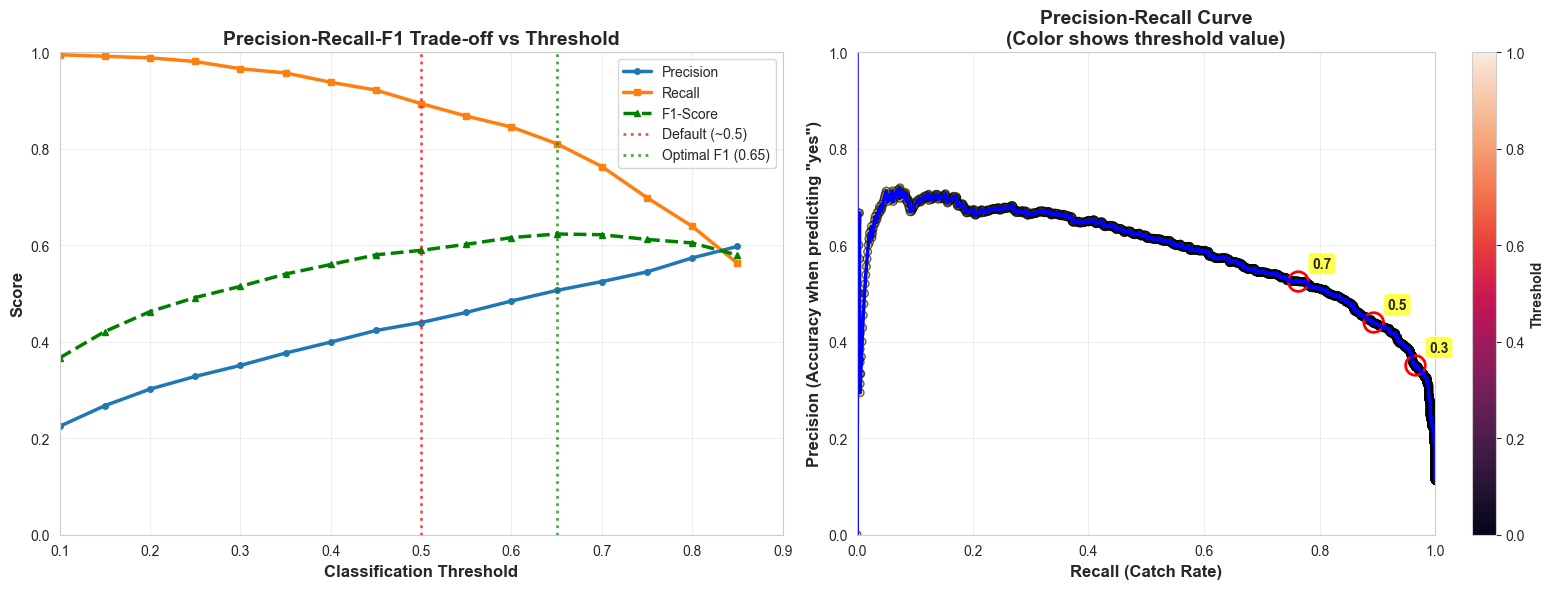


VISUALIZATION COMPLETE

 KEY INSIGHTS FROM PLOTS:
   • LEFT: Shows how metrics change with threshold
   • RIGHT: Shows precision-recall trade-off (each point = different threshold)

 HOW TO READ:
   • Lower threshold → Higher recall, Lower precision
   • Higher threshold → Lower recall, Higher precision
   • Sweet spot depends on your business priorities!


In [50]:
# ========================================================================
# VISUALIZE PRECISION-RECALL TRADE-OFF
# ========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== PLOT 1: Precision, Recall, F1 vs Threshold =====
axes[0].plot(threshold_df['threshold'], threshold_df['precision'], 
                label='Precision', linewidth=2.5, marker='o', markersize=4)
axes[0].plot(threshold_df['threshold'], threshold_df['recall'], 
                label='Recall', linewidth=2.5, marker='s', markersize=4)
axes[0].plot(threshold_df['threshold'], threshold_df['f1'], 
                label='F1-Score', linewidth=2.5, marker='^', markersize=4, 
                linestyle='--', color='green')

# Mark default threshold (0.5) - find closest value
default_idx = (threshold_df['threshold'] - 0.5).abs().idxmin()
default_threshold = threshold_df.loc[default_idx, 'threshold']
axes[0].axvline(x=default_threshold, color='red', linestyle=':', linewidth=2, 
                label=f'Default (~0.5)', alpha=0.7)

# Mark optimal F1 threshold
optimal_f1_idx = threshold_df['f1'].idxmax()
optimal_f1_threshold = threshold_df.loc[optimal_f1_idx, 'threshold']
axes[0].axvline(x=optimal_f1_threshold, color='green', linestyle=':', 
                linewidth=2, label=f'Optimal F1 ({optimal_f1_threshold:.2f})', 
                alpha=0.7)

axes[0].set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Precision-Recall-F1 Trade-off vs Threshold', 
                    fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0.1, 0.9)
axes[0].set_ylim(0, 1)

# ===== PLOT 2: Precision-Recall Curve =====
axes[1].plot(recall, precision, linewidth=2.5, color='blue')
axes[1].scatter(recall[:-1], precision[:-1], c=thresholds_pr, 
                cmap='viridis', s=30, alpha=0.6, edgecolors='black')

# Mark some key thresholds
for thresh_val in [0.3, 0.5, 0.7]:
    idx = (np.abs(thresholds_pr - thresh_val)).argmin()
    axes[1].scatter(recall[idx], precision[idx], s=200, 
                    edgecolors='red', facecolors='none', linewidths=2)
    axes[1].annotate(f'{thresh_val:.1f}', 
                    xy=(recall[idx], precision[idx]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

axes[1].set_xlabel('Recall (Catch Rate)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precision (Accuracy when predicting "yes")', 
                    fontsize=12, fontweight='bold')
axes[1].set_title('Precision-Recall Curve\n(Color shows threshold value)', 
                    fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

# Add colorbar
cbar = plt.colorbar(axes[1].collections[1], ax=axes[1])
cbar.set_label('Threshold', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VISUALIZATION COMPLETE")
print("="*70)
print("\n KEY INSIGHTS FROM PLOTS:")
print("   • LEFT: Shows how metrics change with threshold")
print("   • RIGHT: Shows precision-recall trade-off (each point = different threshold)")
print("\n HOW TO READ:")
print("   • Lower threshold → Higher recall, Lower precision")
print("   • Higher threshold → Lower recall, Higher precision")
print("   • Sweet spot depends on your business priorities!")
    


#### Find Optimal Threshold for Business Goals
- Use metrics to select threshold based on whether you prioritize recall, precision, or balance (F1-score) for the "yes" class.


In [53]:
# ========================================================================
# FIND OPTIMAL THRESHOLDS FOR DIFFERENT SCENARIOS
# ========================================================================

print("="*70)
print("OPTIMAL THRESHOLDS FOR DIFFERENT BUSINESS SCENARIOS")
print("="*70)

# 1. MAXIMUM RECALL (catch as many subscribers as possible)
# Find threshold that gives at least 95% recall
high_recall_df = threshold_df[threshold_df['recall'] >= 0.95]
if len(high_recall_df) > 0:
    # Among those, pick the one with highest precision
    max_recall_idx = high_recall_df['precision'].idxmax()
    max_recall_threshold = threshold_df.loc[max_recall_idx, 'threshold']
    max_recall_metrics = threshold_df.loc[max_recall_idx]
else:
    # If 95% not achievable, just get maximum recall
    max_recall_idx = threshold_df['recall'].idxmax()
    max_recall_threshold = threshold_df.loc[max_recall_idx, 'threshold']
    max_recall_metrics = threshold_df.loc[max_recall_idx]

# 2. BALANCED F1-SCORE (best overall balance)
optimal_f1_idx = threshold_df['f1'].idxmax()
optimal_f1_threshold = threshold_df.loc[optimal_f1_idx, 'threshold']
optimal_f1_metrics = threshold_df.loc[optimal_f1_idx]

# 3. HIGH PRECISION (minimize wasted calls)
# Find threshold that gives at least 60% precision
high_precision_df = threshold_df[threshold_df['precision'] >= 0.60]
if len(high_precision_df) > 0:
    # Among those, pick the one with highest recall
    max_precision_idx = high_precision_df['recall'].idxmax()
    max_precision_threshold = threshold_df.loc[max_precision_idx, 'threshold']
    max_precision_metrics = threshold_df.loc[max_precision_idx]
else:
    # If 60% not achievable, get maximum precision
    max_precision_idx = threshold_df['precision'].idxmax()
    max_precision_threshold = threshold_df.loc[max_precision_idx, 'threshold']
    max_precision_metrics = threshold_df.loc[max_precision_idx]

# 4. DEFAULT (0.5 threshold) - find closest value
default_idx = (threshold_df['threshold'] - 0.5).abs().idxmin()
default_metrics = threshold_df.loc[default_idx]
default_threshold_val = threshold_df.loc[default_idx, 'threshold']

# Create comparison table
scenarios = []

scenarios.append({
    'Scenario': 'MAX RECALL',
    'Goal': 'Catch max subscribers',
    'Threshold': f"{max_recall_threshold:.2f}",
    'Recall': f"{max_recall_metrics['recall']:.3f}",
    'Precision': f"{max_recall_metrics['precision']:.3f}",
    'F1-Score': f"{max_recall_metrics['f1']:.3f}",
    'Calls Needed': f"{max_recall_metrics['tp'] + max_recall_metrics['fp']:.0f}",
    'Subscribers Found': f"{max_recall_metrics['tp']:.0f}"
})

scenarios.append({
    'Scenario': 'BALANCED (F1)',
    'Goal': 'Best overall balance',
    'Threshold': f"{optimal_f1_threshold:.2f}",
    'Recall': f"{optimal_f1_metrics['recall']:.3f}",
    'Precision': f"{optimal_f1_metrics['precision']:.3f}",
    'F1-Score': f"{optimal_f1_metrics['f1']:.3f}",
    'Calls Needed': f"{optimal_f1_metrics['tp'] + optimal_f1_metrics['fp']:.0f}",
    'Subscribers Found': f"{optimal_f1_metrics['tp']:.0f}"
})

scenarios.append({
    'Scenario': 'HIGH PRECISION',
    'Goal': 'Minimize wasted calls',
    'Threshold': f"{max_precision_threshold:.2f}",
    'Recall': f"{max_precision_metrics['recall']:.3f}",
    'Precision': f"{max_precision_metrics['precision']:.3f}",
    'F1-Score': f"{max_precision_metrics['f1']:.3f}",
    'Calls Needed': f"{max_precision_metrics['tp'] + max_precision_metrics['fp']:.0f}",
    'Subscribers Found': f"{max_precision_metrics['tp']:.0f}"
})

# Add default scenario
scenarios.append({
    'Scenario': 'DEFAULT',
    'Goal': 'Standard threshold',
    'Threshold': f"{default_threshold_val:.2f}",
    'Recall': f"{default_metrics['recall']:.3f}",
    'Precision': f"{default_metrics['precision']:.3f}",
    'F1-Score': f"{default_metrics['f1']:.3f}",
    'Calls Needed': f"{default_metrics['tp'] + default_metrics['fp']:.0f}",
    'Subscribers Found': f"{default_metrics['tp']:.0f}"
})

scenarios_df = pd.DataFrame(scenarios)

print("\n" + "="*70)
print("THRESHOLD RECOMMENDATIONS")
print("="*70)
print()
print(scenarios_df.to_string(index=False))

print("\n" + "="*70)
print("BUSINESS IMPACT ANALYSIS")
print("="*70)

# Calculate business impact
total_yes = (y_test == 'yes').sum()

print(f"\n Total potential subscribers in test set: {total_yes}")
print()

for scenario in scenarios:
    if scenario['Scenario'] == ' DEFAULT':
        continue
    print(f"{scenario['Scenario']}: {scenario['Goal']}")
    print(f"   Threshold: {scenario['Threshold']}")
    print(f"   • You need to make {scenario['Calls Needed']} calls")
    print(f"   • You'll reach {scenario['Subscribers Found']} subscribers ({scenario['Recall']} of all)")
    print(f"   • {scenario['Precision']} of your 'yes' predictions will be correct")
    print()

print("="*70)
print(" RECOMMENDATION")
print("="*70)
print("\nFor a BANK MARKETING CAMPAIGN, typically choose:")
print(f"\n OPTIMAL THRESHOLD: {optimal_f1_threshold:.2f} (Balanced F1)")
print(f"   • Recall: {optimal_f1_metrics['recall']:.1%} - Catches most subscribers")
print(f"   • Precision: {optimal_f1_metrics['precision']:.1%} - Good accuracy")
print(f"   • F1-Score: {optimal_f1_metrics['f1']:.3f} - Best balance")

# Store for next cell
recommended_threshold = optimal_f1_threshold
    


OPTIMAL THRESHOLDS FOR DIFFERENT BUSINESS SCENARIOS

THRESHOLD RECOMMENDATIONS

      Scenario                  Goal Threshold Recall Precision F1-Score Calls Needed Subscribers Found
    MAX RECALL Catch max subscribers      0.35  0.957     0.376    0.540         2360               888
 BALANCED (F1)  Best overall balance      0.65  0.810     0.506    0.623         1486               752
HIGH PRECISION Minimize wasted calls      0.85  0.562     0.597    0.579          874               522
       DEFAULT    Standard threshold      0.50  0.893     0.440    0.589         1886               829

BUSINESS IMPACT ANALYSIS

 Total potential subscribers in test set: 928

MAX RECALL: Catch max subscribers
   Threshold: 0.35
   • You need to make 2360 calls
   • You'll reach 888 subscribers (0.957 of all)
   • 0.376 of your 'yes' predictions will be correct

BALANCED (F1): Best overall balance
   Threshold: 0.65
   • You need to make 1486 calls
   • You'll reach 752 subscribers (0.810 of all)


### Apply the optimal threshold to make final predictions and evaluate final model performance on test data.

In [54]:
# ========================================================================
# APPLY CUSTOM THRESHOLD
# ========================================================================
# ============================================================
# CHOOSE YOUR THRESHOLD HERE
# ============================================================
# Options:
# - Use recommended_threshold (from previous cell - optimal F1)
# - Or set manually: custom_threshold = 0.35 (for high recall)
# - Or: custom_threshold = 0.65 (for high precision)

custom_threshold = recommended_threshold  # Change this value to experiment!

print("="*70)
print(f"APPLYING CUSTOM THRESHOLD: {custom_threshold:.2f}")
print("="*70)

# Apply threshold to get predictions
y_pred_custom = (y_probabilities >= custom_threshold).astype(int)

# Convert to 'yes'/'no' labels
y_pred_custom_labels = ['yes' if pred == 1 else 'no' for pred in y_pred_custom]

print(f"\nClassification Report (Threshold = {custom_threshold:.2f}):")
print("="*70)
print(classification_report(y_test, y_pred_custom_labels, target_names=['no', 'yes']))

print("\nConfusion Matrix:")
print("="*70)
cm_custom = confusion_matrix(y_test, y_pred_custom_labels, labels=['no', 'yes'])
print(cm_custom)
print("\nFormat:")
print("           Predicted: no   Predicted: yes")
print(f"Actual: no    [{cm_custom[0,0]:4d}]          [{cm_custom[0,1]:4d}]")
print(f"Actual: yes   [{cm_custom[1,0]:4d}]          [{cm_custom[1,1]:4d}]")

# Calculate ROC-AUC
from sklearn.metrics import roc_auc_score
roc_auc_custom = roc_auc_score(y_test, y_probabilities)
print(f"\nROC-AUC Score: {roc_auc_custom:.4f}")

# Business metrics
tp = cm_custom[1,1]
fp = cm_custom[0,1]
tn = cm_custom[0,0]
fn = cm_custom[1,0]

total_calls = tp + fp
total_subscribers = tp + fn

recall_custom = tp / (tp + fn)
precision_custom = tp / (tp + fp) if (tp + fp) > 0 else 0
f1_custom = 2 * (precision_custom * recall_custom) / (precision_custom + recall_custom) if (precision_custom + recall_custom) > 0 else 0

print("\n" + "="*70)
print("BUSINESS METRICS")
print("="*70)
print(f"\nSubscribers to call: {total_calls:,}")
print(f"   • Actual subscribers reached: {tp} (Recall: {recall_custom:.1%})")
print(f"   • Non-subscribers called: {fp} (Wasted effort)")

print(f"\nSubscribers missed: {fn} ({fn/total_subscribers:.1%} of all subscribers)")

print(f"\nPerformance:")
print(f"   • Recall:    {recall_custom:.3f} ← Catch {recall_custom:.1%} of subscribers")
print(f"   • Precision: {precision_custom:.3f} ← {precision_custom:.1%} accuracy when predicting 'yes'")
print(f"   • F1-Score:  {f1_custom:.3f} ← Overall balance")

# Compare to default 0.5 threshold
if abs(custom_threshold - 0.5) > 0.01:
    y_pred_default = (y_probabilities >= 0.5).astype(int)
    y_pred_default_labels = ['yes' if pred == 1 else 'no' for pred in y_pred_default]
    cm_default = confusion_matrix(y_test, y_pred_default_labels, labels=['no', 'yes'])
    
    tp_default = cm_default[1,1]
    fp_default = cm_default[0,1]
    fn_default = cm_default[1,0]
    
    recall_default = tp_default / (tp_default + fn_default)
    precision_default = tp_default / (tp_default + fp_default) if (tp_default + fp_default) > 0 else 0
    
    print("\n" + "="*70)
    print(f"COMPARISON: Custom ({custom_threshold:.2f}) vs Default (0.50)")
    print("="*70)
    print(f"\n📈 Recall Change: {recall_default:.1%} → {recall_custom:.1%} ({recall_custom - recall_default:+.1%})")
    print(f"📈 Precision Change: {precision_default:.1%} → {precision_custom:.1%} ({precision_custom - precision_default:+.1%})")
    print(f"📈 Extra subscribers caught: {tp - tp_default:+d}")
    print(f"📈 Extra calls needed: {(tp + fp) - (tp_default + fp_default):+d}")

print("\n" + "="*70)
print("THRESHOLD ADJUSTMENT COMPLETE!")
print("="*70)
print(f"\nTo try different threshold, change 'custom_threshold' value above and re-run.")
print(f"Current: {custom_threshold:.2f}")
print(f"\nSuggestions to try:")
print(f"  • {max_recall_threshold:.2f} - Maximum recall")
print(f"  • {optimal_f1_threshold:.2f} - Optimal F1 (balanced)")
print(f"  • {max_precision_threshold:.2f} - High precision")
    


APPLYING CUSTOM THRESHOLD: 0.65

Classification Report (Threshold = 0.65):
              precision    recall  f1-score   support

          no       0.97      0.90      0.94      7308
         yes       0.51      0.81      0.62       928

    accuracy                           0.89      8236
   macro avg       0.74      0.85      0.78      8236
weighted avg       0.92      0.89      0.90      8236


Confusion Matrix:
[[6574  734]
 [ 176  752]]

Format:
           Predicted: no   Predicted: yes
Actual: no    [6574]          [ 734]
Actual: yes   [ 176]          [ 752]

ROC-AUC Score: 0.9376

BUSINESS METRICS

Subscribers to call: 1,486
   • Actual subscribers reached: 752 (Recall: 81.0%)
   • Non-subscribers called: 734 (Wasted effort)

Subscribers missed: 176 (19.0% of all subscribers)

Performance:
   • Recall:    0.810 ← Catch 81.0% of subscribers
   • Precision: 0.506 ← 50.6% accuracy when predicting 'yes'
   • F1-Score:  0.623 ← Overall balance

COMPARISON: Custom (0.65) vs Default 

### Summary: Threshold Adjustment Guide

**What You've Learned:**

1. **Default threshold (0.5) is not always optimal** - It's just a starting point
2. **Lower threshold** (0.3-0.4) → Higher Recall, Lower Precision
3. **Higher threshold** (0.6-0.7) → Lower Recall, Higher Precision
4. **Use the precision-recall curve** to find the sweet spot for your business

**How to Choose the Right Threshold:**

| Business Priority | Recommended Threshold | Why |
|------------------|---------------------|-----|
| **Max customer acquisition** | 0.30 - 0.40 | Catch almost all subscribers, accept more false positives |
| **Balanced approach** | Optimal F1 threshold | Best trade-off between precision and recall |
| **Cost-conscious** | 0.60 - 0.70 | Only call high-confidence leads |
| **Regulatory/Conservative** | 0.70 - 0.80 | Minimize false positives |

**Next Steps:**

- Run all the threshold cells above
- Review the precision-recall visualization
- Try different thresholds in the "Apply Custom Threshold" cell
- Choose the one that best fits your marketing budget and goals

**Pro Tip:** For bank marketing campaigns, typically aim for **70-80% recall** with the best precision you can get. This ensures you're catching most subscribers without wasting too many calls.

### Apply Custom Threshold and Evaluate

My threshold is "Max customer acquisition" (0.30 - 0.40) to catch as many subscribers as possible, even if it means more false positives. This is because the value of acquiring a new customer likely outweighs the cost of a few wasted calls.    

In [55]:
# ========================================================================
# APPLY MAX CUSTOMER ACQUISITION STRATEGY (Threshold: 0.30-0.40)
# ========================================================================
print("="*70)
print("MAX CUSTOMER ACQUISITION STRATEGY")
print("="*70)

# Use aggressive threshold for maximum recall
# Testing threshold = 0.35 (adjust between 0.30-0.40 as needed)
max_acquisition_threshold = 0.35

print(f"\nApplying threshold: {max_acquisition_threshold:.2f}")
print("Goal: Catch MAXIMUM subscribers, accepting more false positives")

# Apply threshold to get predictions
y_pred_max_acq = (y_probabilities >= max_acquisition_threshold).astype(int)

# Convert to 'yes'/'no' labels
y_pred_max_acq_labels = ['yes' if pred == 1 else 'no' for pred in y_pred_max_acq]

# ============================================================
# EVALUATION
# ============================================================
print(f"\nClassification Report (Threshold = {max_acquisition_threshold:.2f}):")
print("="*70)
print(classification_report(y_test, y_pred_max_acq_labels, target_names=['no', 'yes']))

print("\nConfusion Matrix:")
print("="*70)
cm_max_acq = confusion_matrix(y_test, y_pred_max_acq_labels, labels=['no', 'yes'])
print(cm_max_acq)
print("\nFormat:")
print("           Predicted: no   Predicted: yes")
print(f"Actual: no    [{cm_max_acq[0,0]:4d}]          [{cm_max_acq[0,1]:4d}]  ← TN / FP")
print(f"Actual: yes   [{cm_max_acq[1,0]:4d}]          [{cm_max_acq[1,1]:4d}]  ← FN / TP")

# Calculate ROC-AUC
roc_auc_max_acq = roc_auc_score(y_test, y_probabilities)
print(f"\nROC-AUC Score: {roc_auc_max_acq:.4f}")

# Business metrics
tp = cm_max_acq[1,1]
fp = cm_max_acq[0,1]
tn = cm_max_acq[0,0]
fn = cm_max_acq[1,0]

total_calls = tp + fp
total_subscribers = tp + fn
subscribers_caught = tp
subscribers_missed = fn

recall_max_acq = tp / (tp + fn) if (tp + fn) > 0 else 0
precision_max_acq = tp / (tp + fp) if (tp + fp) > 0 else 0
f1_max_acq = 2 * (precision_max_acq * recall_max_acq) / (precision_max_acq + recall_max_acq) if (precision_max_acq + recall_max_acq) > 0 else 0

# ============================================================
# BUSINESS IMPACT ANALYSIS
# ============================================================
print("\n" + "="*70)
print("BUSINESS IMPACT - MAX ACQUISITION STRATEGY")
print("="*70)

print(f"\nCAMPAIGN SCOPE:")
print(f"   Total calls to make: {total_calls:,}")
print(f"   Total test set size: {len(y_test):,}")
print(f"   Call {total_calls/len(y_test):.1%} of your customer base")

print(f"\nSUBSCRIBERS CAUGHT:")
print(f"   Subscribers you'll reach: {subscribers_caught} out of {total_subscribers}")
print(f"   Catch rate (Recall): {recall_max_acq:.1%}")
print(f"   Subscribers missed: {subscribers_missed} ({subscribers_missed/total_subscribers:.1%})")

print(f"\nFALSE POSITIVES (Wasted Effort):")
print(f"   Non-subscribers called: {fp:,}")
print(f"   Precision: {precision_max_acq:.1%} (accuracy when predicting 'yes')")
print(f"   For every 100 'yes' predictions, {int(precision_max_acq * 100)} are correct")

print(f"\nBUSINESS TRADE-OFF:")
print(f"   Calls needed per subscriber: {total_calls/subscribers_caught:.1f} calls")
print(f"   Wasted calls per subscriber: {fp/subscribers_caught:.1f} calls")

# Compare to default threshold (0.5)
y_pred_default = (y_probabilities >= 0.5).astype(int)
y_pred_default_labels = ['yes' if pred == 1 else 'no' for pred in y_pred_default]
cm_default = confusion_matrix(y_test, y_pred_default_labels, labels=['no', 'yes'])

tp_default = cm_default[1,1]
fp_default = cm_default[0,1]
fn_default = cm_default[1,0]

recall_default = tp_default / (tp_default + fn_default) if (tp_default + fn_default) > 0 else 0
precision_default = tp_default / (tp_default + fp_default) if (tp_default + fp_default) > 0 else 0

print("\n" + "="*70)
print(f"COMPARISON: Aggressive ({max_acquisition_threshold:.2f}) vs Default (0.50)")
print("="*70)

print(f"\nRecall (Catch Rate):")
print(f"   Default (0.50): {recall_default:.1%}")
print(f"   Max Acq ({max_acquisition_threshold:.2f}): {recall_max_acq:.1%}")
print(f"   Change: {recall_max_acq - recall_default:+.1%} ({abs(tp - tp_default)} more subscribers caught)")

print(f"\nPrecision (Accuracy):")
print(f"   Default (0.50): {precision_default:.1%}")
print(f"   Max Acq ({max_acquisition_threshold:.2f}): {precision_max_acq:.1%}")
print(f"   Change: {precision_max_acq - precision_default:+.1%}")

print(f"\nCall Volume:")
print(f"   Default (0.50): {tp_default + fp_default:,} calls")
print(f"   Max Acq ({max_acquisition_threshold:.2f}): {total_calls:,} calls")
print(f"   Extra calls needed: {total_calls - (tp_default + fp_default):+,} ({(total_calls - (tp_default + fp_default))/len(y_test):.1%} increase)")

print("\n" + "="*70)
print("RECOMMENDATION")
print("="*70)
print(f"\nUse this {max_acquisition_threshold:.2f} threshold if:")
print(f"   Customer lifetime value is HIGH (each subscriber is valuable)")
print(f"   Cost per call is LOW (phone calls are cheap)")
print(f"   Missing subscribers is COSTLY (lost revenue opportunity)")
print(f"   You have capacity for {total_calls:,} calls")

print(f"\nDON'T use this threshold if:")
print(f"   Contact costs are HIGH (expensive marketing)")
print(f"   You have limited call capacity")
print(f"   False positives hurt brand reputation")

print("\n" + "="*70)
print("MAX ACQUISITION ANALYSIS COMPLETE!")
print("="*70)
print(f"\nTo adjust the threshold:")
print(f"   • Try 0.30 for even MORE recall (catches ~95%+ subscribers)")
print(f"   • Try 0.40 for slightly better precision (still ~85%+ recall)")
print(f"   • Current: {max_acquisition_threshold:.2f} (balanced aggressive approach)")
    


MAX CUSTOMER ACQUISITION STRATEGY

Applying threshold: 0.35
Goal: Catch MAXIMUM subscribers, accepting more false positives

Classification Report (Threshold = 0.35):
              precision    recall  f1-score   support

          no       0.99      0.80      0.89      7308
         yes       0.38      0.96      0.54       928

    accuracy                           0.82      8236
   macro avg       0.68      0.88      0.71      8236
weighted avg       0.92      0.82      0.85      8236


Confusion Matrix:
[[5836 1472]
 [  40  888]]

Format:
           Predicted: no   Predicted: yes
Actual: no    [5836]          [1472]  ← TN / FP
Actual: yes   [  40]          [ 888]  ← FN / TP

ROC-AUC Score: 0.9376

BUSINESS IMPACT - MAX ACQUISITION STRATEGY

CAMPAIGN SCOPE:
   Total calls to make: 2,360
   Total test set size: 8,236
   Call 28.7% of your customer base

SUBSCRIBERS CAUGHT:
   Subscribers you'll reach: 888 out of 928
   Catch rate (Recall): 95.7%
   Subscribers missed: 40 (4.3%)

FALS